
# 🏁 iRacing Telemetry → Coaching Pipeline (End-to-End)

This notebook builds a **complete, reproducible pipeline** to turn iRacing telemetry into **sector-level coaching**.

You will:
1. **Load** raw telemetry (from `.ibt` via `irsdk` or from a pre-saved CSV).
2. **Clean & normalize** the signals; convert units.
3. **Align laps** by distance percentage and visualize **time loss vs reference**.
4. **Split the lap into sectors**, compute sector statistics and deltas.
5. Build a **robust sector reference** (median of the top K% fastest laps).
6. Engineer features, **train a regressor** (LightGBM fallback to GradientBoosting), and report cross-validated metrics.
7. Apply a **per-sector residual bias correction** and re-evaluate metrics.
8. Generate **rule-based coaching** in milliseconds (ms).
9. (Optional) Call a **local LLM via Ollama** to produce **professional English coaching** using a structured JSON context.

> **Note:** All visuals use Matplotlib. No external internet is required. If `irsdk` is unavailable, you can work from CSV.



## 1. Environment checks & configuration

Fill the paths and flags below. If you don't have `.ibt` or `irsdk`, set `USE_IBT=False` and point to a CSV created earlier.


In [1]:

# --- Imports
import os, folium
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from collections import Counter
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False




In [2]:
# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available

# Core pipeline settings
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42



# Configuration

In [ ]:
DATASETS = {

    # =========================
    # MAZDA MX-5 — CHARLOTTE
    # =========================
    "charlotte_roval_2025": {
        "base_path": "G:/Meu Drive/Estudos/Datasets - Simracing/Mazda - Charlotte/",
        "car": "Mazda MX-5",
        "sessions": {
            "Tomaz": {
                "stint_1": "mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt"
            },
            "Morsinaldo": {
                "stint_1": "mx5 mx52016_charlotte 2025 roval2025 2026-01-27 16-13-55(Morsinaldo).ibt",
                "stint_2": "mx5 mx52016_charlotte 2025 roval2025 2026-01-28 15-24-41(Morsinaldo).ibt"
            },
            "Rodrigo": {
                #"stint_1": "mx5 mx52016_charlotte 2025 roval2025 2026-02-08 14-08-55(Rodrigo).ibt",
                #"stint_2": "mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-04-32(Rodrigo).ibt",
                "stint_1": "mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt" #antigo stint 3
            }
        }
    },

    # =========================
    # TOYOTA GR86 — SUMMIT POINT
    # =========================
    "summit_point": {
        "base_path": "G:/Meu Drive/Estudos/Datasets - Simracing/Toyota GR86 - Summit Point/",
        "car": "Toyota GR86",
        "sessions": {
            "Tomaz": {
                "stint_1": "toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt"
            },
            "Morsinaldo": {
                "stint_1": "toyotagr86_summit summit raceway 2026-01-28 16-03-13(Morsinaldo).ibt",
                "stint_2": "toyotagr86_summit summit raceway 2026-01-30 08-56-59(Morsinaldo).ibt"
            },
            "Rodrigo": {
                "stint_1": "toyotagr86_summit summit raceway 2026-03-01 22-00-14(Rodrigo).ibt" 
            }
        }
    }
}

TRACK_CONFIG_MAP = {
    "charlotte_roval_2025": "config_roval_2025",
    "summit_point": "config_summit_point",
}

In [4]:
DRIVER_ALIAS = {
    "Rodrigo":    "Driver A",
    "Tomaz":      "Driver B",
    "Morsinaldo": "Driver C",
}

# User Selection

In [5]:
# =========================
# USER SELECTION
# =========================

TRACK = "summit_point"  # options: "charlotte_roval_2025", "summit_point"

# Piloto de referência (baseline)
DRIVER_REF  = "Rodrigo"
STINT_REF   = "stint_3"

# Piloto em avaliação
DRIVER_TEST = "Tomaz"
STINT_TEST  = "stint_1"




In [6]:
# Aliases para uso em labels/títulos/plots
driver_a = DRIVER_ALIAS.get(DRIVER_REF,  DRIVER_REF)
driver_b = DRIVER_ALIAS.get(DRIVER_TEST, DRIVER_TEST)

BASE_PATH  = DATASETS[TRACK]["base_path"]
ibt_file_A = BASE_PATH + DATASETS[TRACK]["sessions"][DRIVER_REF][STINT_REF]   # usa nome real
ibt_file_B = BASE_PATH + DATASETS[TRACK]["sessions"][DRIVER_TEST][STINT_TEST] # usa nome real

print("Reference :", driver_a, STINT_REF)
print("Test      :", driver_b, STINT_TEST)

Reference : Driver A stint_3
Test      : Driver B stint_1


# Import Track Sectors Edge

In [7]:
import sys
import importlib
from pathlib import Path

# Autoreload (Jupyter)
%load_ext autoreload
%autoreload 2

# 1. Resolve nome do módulo de config da pista primeiro
config_module_name = TRACK_CONFIG_MAP[TRACK]

# 2. Define os caminhos possíveis
caminhos_possiveis = [
    Path.home() / "OneDrive" / "Documents" / "GitHub" / "Doutorado" / "Racing4all",
    Path.home() / "Documents" / "GitHub" / "Racing4all"
]

CONFIG_TRACKS_PATH = None

# 3. Procura o caminho que contém ESPECIFICAMENTE o arquivo da pista atual
for base in caminhos_possiveis:
    tentativa_pasta = base / "Iracing" / "config_tracks"
    tentativa_arquivo = tentativa_pasta / f"{config_module_name}.py"
    
    # Verifica se a pasta e o arquivo .py existem fisicamente na máquina
    if tentativa_arquivo.exists():
        CONFIG_TRACKS_PATH = tentativa_pasta
        break

# 4. Trava o código com um aviso claro se o arquivo não estiver no PC
if CONFIG_TRACKS_PATH is None:
    raise FileNotFoundError(
        f"\nERRO: O arquivo '{config_module_name}.py' não foi encontrado!\n"
        f"Verifique se você fez o 'git pull' neste computador ou se o nome da pasta está correto."
    )

# 5. Adiciona no INÍCIO do sys.path (prioridade máxima)
if str(CONFIG_TRACKS_PATH) not in sys.path:
    sys.path.insert(0, str(CONFIG_TRACKS_PATH))

# 6. Import dinâmico
config_module = importlib.import_module(config_module_name)

# 7. Exporta para o notebook
CUSTOM_EDGES  = config_module.CUSTOM_EDGES
SECTOR_NAMES  = config_module.SECTOR_NAMES
TRACK_NAME    = config_module.TRACK_NAME

print(f"Configuração carregada: {TRACK_NAME}")
print(f"Caminho utilizado: {CONFIG_TRACKS_PATH}")
print(f"Número de setores: {len(CUSTOM_EDGES) - 1}")

Configuração carregada: Summit Point - Main Circuit
Caminho utilizado: C:\Users\PC\Documents\GitHub\Racing4all\Iracing\config_tracks
Número de setores: 10


In [8]:
# ── Output directory — mirrors lap time notebook structure ─────────
PROJECT_ROOT = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all"
BASE_IMG_DIR = Path(PROJECT_ROOT) / "Iracing" / "img"

COMPARISON_ID = f"{TRACK}_{driver_a}_vs_{driver_b}"
SAVE_DIR = BASE_IMG_DIR / TRACK / COMPARISON_ID 
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {SAVE_DIR}")


Output directory: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\summit_point\summit_point_Driver A_vs_Driver B


# 2. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [9]:
USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = [
        'Lat',
        'Lon',
        # Tempo / lap
        'SessionTime',
        'Lap',
        'LapDistPct',

        # Inputs
        'Throttle',
        'ThrottleRaw',
        'Brake',
        'BrakeRaw',
        'SteeringWheelAngle',

        # Dinâmica
        'Speed',
        'LatAccel',
        'LongAccel',
        'YawRate',

        # Contexto
        'RPM',
        'Gear',
        'BrakeABSactive',
    ]
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)


raw_df = load_from_ibt(Path(ibt_file_A))
raw_df.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive
0,0.000000,0.000000,2002.166666,0,0.000000,0.0,0.0,1.0,0.0,0.177539,0.000000,0.205870,0.224684,0.001440,300.0,0,False
1,39.236732,-77.968762,2002.183332,19,0.948028,0.0,0.0,1.0,0.0,0.177539,0.004645,0.721032,-0.526836,0.005737,300.0,0,False
2,39.236732,-77.968762,2002.199999,19,0.948028,0.0,0.0,1.0,0.0,0.177539,0.014408,0.580677,-0.406024,0.006290,300.0,0,False
3,39.236732,-77.968762,2002.216666,19,0.948028,0.0,0.0,1.0,0.0,0.177539,0.027175,1.403255,0.066302,0.002156,300.0,0,False
4,39.236732,-77.968762,2002.233332,19,0.948028,0.0,0.0,1.0,0.0,0.177299,0.034118,0.354014,0.414042,-0.001366,300.0,0,False


# 3) Data Cleaning



In [38]:
import pandas as pd
import numpy as np
from typing import Optional, Dict

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: Optional[set] = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
    min_lap_time_s: float = 45.0,  # <-- NOVO: Corte para ignorar resets/tows (Ajuste se for oval curto)
    max_lap_time_s: float = 120.0,
) -> pd.DataFrame:

    manual_invalid = manual_invalid or set()
    rows = []

    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime").copy()
        lap_time = lap_time_seconds(gs)

        rows.append({
            "Lap": int(lap),
            "LapTime_s": float(lap_time),
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })

    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)

    # Nova regra de validade incluindo o min_lap_time_s
    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct) &
        (~lap_df["Lap"].isin(manual_invalid)) &
        (lap_df["FracLowSpeed"] <= 0.25) &
        (lap_df["MaxSpeed_kph"] >= min_max_speed_kph) &
        (lap_df["LapTime_s"] >= min_lap_time_s) &  # <-- NOVO: Impede voltas anomalamente curtas
        (lap_df["LapTime_s"] <= max_lap_time_s)
    )
    lap_df["Valid"] = valid

    # Agora o IQR será calculado apenas em cima de voltas "plausíveis"
    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1)
        hi = float(q3 + 1.5 * iqr)
        lo = max(0.0, float(q1 - 1.5 * iqr))
        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)

    return lap_df

def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty: return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()

    if len(x) < 2 or np.allclose(x.max() - x.min(), 0): return {}

    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)

    return {
        "LapDistPct": grid,
        "t_rel": interp(t_rel.to_numpy()),
        "speed": interp(g["Speed_KPH"].to_numpy()),
        "throttle": interp(g["Throttle_Pct"].to_numpy()),
        "brake": interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
        # ADICIONE ESTES DOIS PARA O DOUTORADO:
        "YawRate": interp(g.get("YawRate", np.zeros_like(x)).to_numpy()),
        "LongAccel": interp(g.get("LongAccel", np.zeros_like(x)).to_numpy())
    }


def format_laptime(seconds: float) -> str:
    """Converte um tempo em segundos para o formato de string MM:SS.ms."""
    if pd.isna(seconds):
        return "N/A"
    # Calcula os minutos
    minutes = int(seconds // 60)
    # Calcula os segundos restantes com milissegundos
    remaining_seconds = seconds % 60
    # Retorna a string formatada, garantindo dois dígitos para os minutos
    # e preenchimento com zero para os segundos (ex: 01:05.123)
    return f"{minutes:02d}:{remaining_seconds:06.3f}"

def normalize_lapdistpct(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "LapDistPct" not in df.columns:
        return df

    mx = df["LapDistPct"].max()
    # Heurística simples: se parece 0-100, normaliza
    if pd.notna(mx) and mx > 1.5:
        df["LapDistPct"] = df["LapDistPct"] / 100.0

    return df

def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Unidades (antes de dropna)
    if "Speed_KPH" not in df.columns and "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6
    if "Throttle_Pct" not in df.columns and "Throttle" in df.columns:
        df["Throttle_Pct"] = df["Throttle"] * 100.0
    if "Brake_Pct" not in df.columns and "Brake" in df.columns:
        df["Brake_Pct"] = df["Brake"] * 100.0

    # Normaliza LapDistPct
    df = normalize_lapdistpct(df)

    required = ["Lap", "SessionTime", "LapDistPct", "Speed_KPH", "Throttle_Pct", "Brake_Pct"]
    required = [c for c in required if c in df.columns]
    df = df.dropna(subset=required)

    return df

In [39]:
df_ref = basic_clean_and_units(raw_df)
df_ref.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,0.000000,0.000000,2002.166666,0,0.000000,0.0,0.0,1.0,0.0,0.177539,0.000000,0.205870,0.224684,0.001440,300.0,0,False,0.000000,0.0,100.0
1,39.236732,-77.968762,2002.183332,19,0.948028,0.0,0.0,1.0,0.0,0.177539,0.004645,0.721032,-0.526836,0.005737,300.0,0,False,0.016721,0.0,100.0
2,39.236732,-77.968762,2002.199999,19,0.948028,0.0,0.0,1.0,0.0,0.177539,0.014408,0.580677,-0.406024,0.006290,300.0,0,False,0.051868,0.0,100.0
3,39.236732,-77.968762,2002.216666,19,0.948028,0.0,0.0,1.0,0.0,0.177539,0.027175,1.403255,0.066302,0.002156,300.0,0,False,0.097829,0.0,100.0
4,39.236732,-77.968762,2002.233332,19,0.948028,0.0,0.0,1.0,0.0,0.177299,0.034118,0.354014,0.414042,-0.001366,300.0,0,False,0.122826,0.0,100.0



## 4. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [40]:
INVALID_LAPS = set()
TARGET_LAP_TO_ANALYZE = 26

lap_df = build_lap_validity_table(df_ref, manual_invalid=INVALID_LAPS)

lap_df["LapTime_Formatted"] = lap_df["LapTime_s"].apply(format_laptime)

display(lap_df[["Lap", "Valid", "LapTime_s", "LapTime_Formatted"]])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada.")

# --- Referência: volta mais rápida válida ---
ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])

# --- Target: tentativa manual com fallback ---
target_lap = TARGET_LAP_TO_ANALYZE

if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não existe ou é inválida.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)

target_row = lap_df.loc[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,773.000000,12:53.000
1,19,False,14.300000,00:14.300
2,20,False,82.616667,01:22.617
3,21,False,80.750000,01:20.750
4,22,False,21.016667,00:21.017
5,23,True,78.983333,01:18.983
6,24,True,79.250000,01:19.250
7,25,True,79.033333,01:19.033
8,26,False,78.016667,01:18.017
9,27,False,6.983333,00:06.983


⚠️ Volta alvo 26 não existe ou é inválida.
Usando a volta válida mais lenta como fallback.
Reference lap: 23  (01:18.983)
Target lap   : 31  (01:19.200)


# Import other driver telemetry

In [41]:
raw_df_test = load_from_ibt(Path(ibt_file_B))
#Data Cleaning
df_test = basic_clean_and_units(raw_df_test)
df_test.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct
0,0.000000,0.000000,71.716665,0,0.000000,0.0,0.0,1.0,0.0,0.012508,0.000000,0.717065,-0.158037,-0.001541,300.0,0,False,0.000000,0.0,100.0
1,39.240666,-77.971284,71.733332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.009011,-0.819917,-0.011085,-0.002227,300.0,0,False,0.032440,0.0,100.0
2,39.240666,-77.971284,71.749999,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.008718,-0.288280,0.501410,0.000168,300.0,0,False,0.031385,0.0,100.0
3,39.240666,-77.971284,71.766665,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.011934,-0.434874,0.808939,0.001219,300.0,0,False,0.042963,0.0,100.0
4,39.240666,-77.971284,71.783332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.026418,-0.427604,0.867212,0.002939,300.0,0,False,0.095104,0.0,100.0


In [42]:
#Cleaning lap time
INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
target_lap = 10 # Tentativa de usar a volta desejada


#retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(df_test, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada para este piloto.")

# Volta de referência (mais rápida válida)
ref_row_test = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row_test["Lap"])


if target_lap not in valid_laps:
    print(
        f"⚠️ Volta alvo {target_lap} não disponível para este piloto.\n"
        f"Usando a volta válida mais lenta como fallback."
    )
    target_lap = max(valid_laps)
    
target_row = lap_df[lap_df["Lap"] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,999.700000,16:39.700
1,1,False,82.066667,01:22.067
2,2,True,80.250000,01:20.250
3,3,False,82.783333,01:22.783
4,4,True,80.483333,01:20.483
5,5,True,80.616667,01:20.617
6,6,True,80.500000,01:20.500
7,7,True,80.333333,01:20.333
8,8,True,79.766667,01:19.767
9,9,True,80.316667,01:20.317


Reference lap: 8  (01:18.983)
Target lap   : 10  (01:19.967)



## 5. Lap alignment & quick plots

We align laps by **LapDistPct** to compare signals and compute **time loss vs reference**.


Saving figures to:
C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\summit_point\summit_point_Driver A_vs_Driver B\stint_3_vs_stint_1
REF  - Driver A (stint_3): Lap 23 (01:18.983)
TEST - Driver B (stint_1): Lap 8 (01:19.767)
Saved: delta_loss_summit_point_Driver A_vs_Driver B_stint_3_vs_stint_1.png


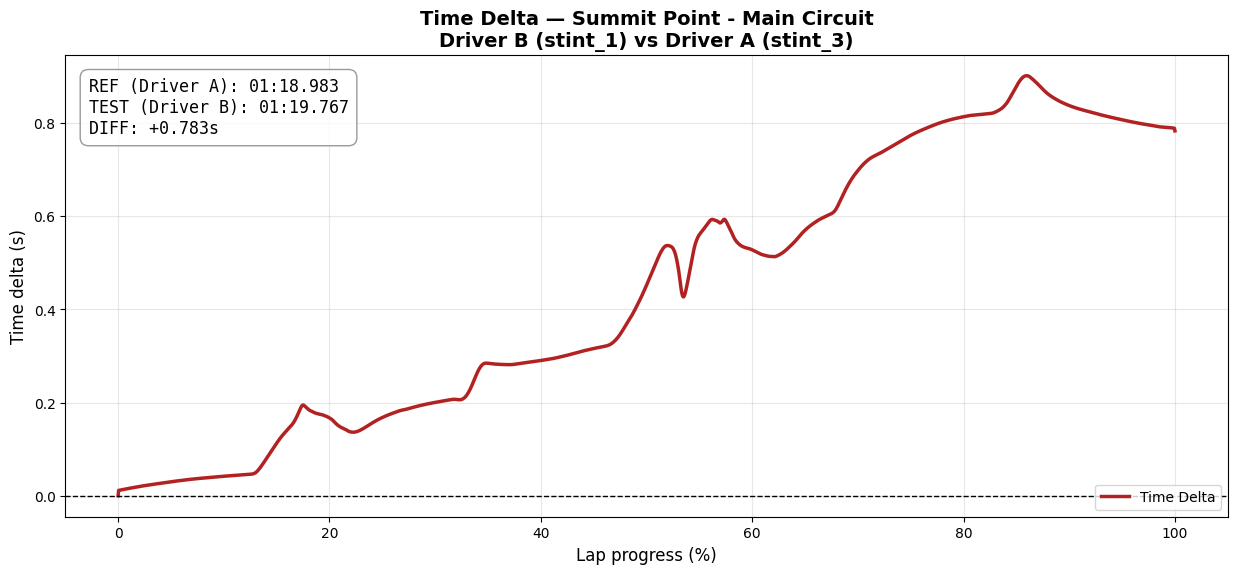

Saved: telemetry_speed_summit_point_Driver A_vs_Driver B_stint_3_vs_stint_1.png


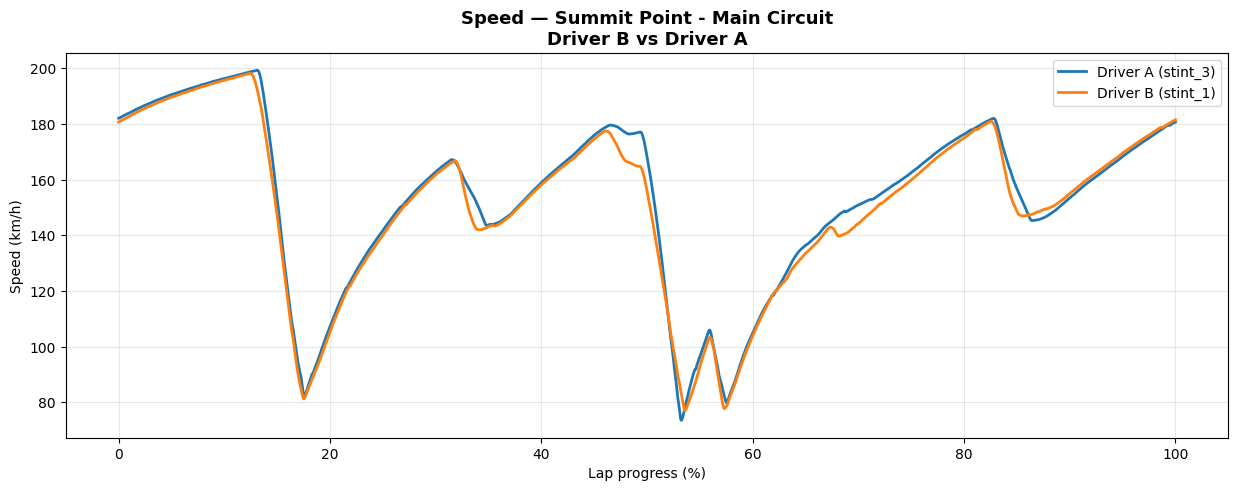

Saved: telemetry_throttle_summit_point_Driver A_vs_Driver B_stint_3_vs_stint_1.png


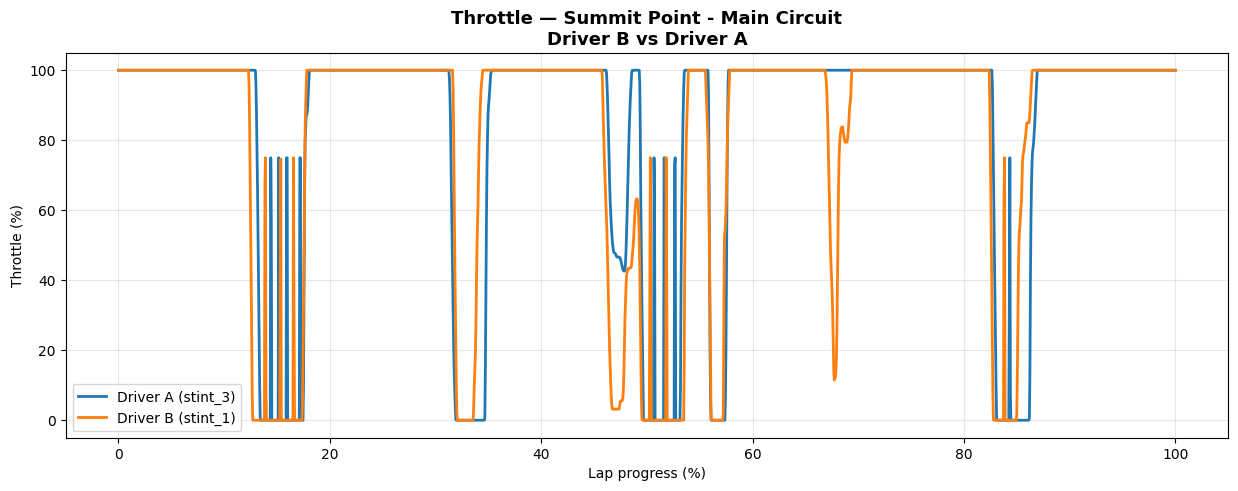

Saved: telemetry_brake_summit_point_Driver A_vs_Driver B_stint_3_vs_stint_1.png


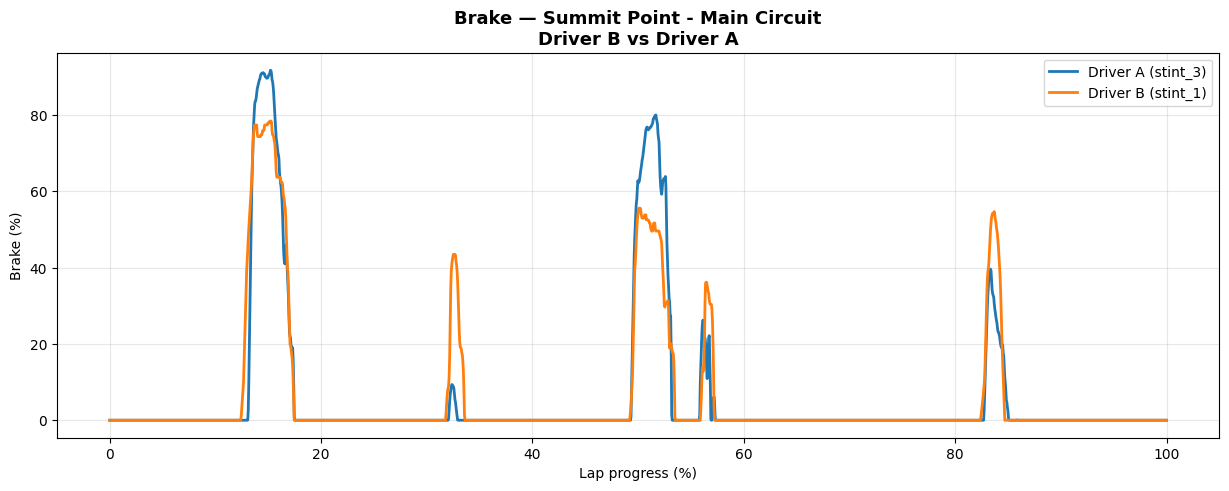

In [43]:
# =========================================================
# DELTA LOSS + QUICK PLOTS (REF vs TEST)
# =========================================================

# ---------------------------------------------------------
# 1. DIRETÓRIO DE SAÍDA
# ---------------------------------------------------------
BASE_IMG_DIR  = Path(PROJECT_ROOT) / "Iracing/img"
COMPARISON_ID = f"{TRACK}_{driver_a}_vs_{driver_b}"
SAVE_DIR      = BASE_IMG_DIR / TRACK / COMPARISON_ID / f"{STINT_REF}_vs_{STINT_TEST}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Saving figures to:\n{SAVE_DIR}")

# ---------------------------------------------------------
# 2. BEST LAP (REF E TEST)
# ---------------------------------------------------------
lap_df_ref  = build_lap_validity_table(df_ref)
best_row_ref  = lap_df_ref[lap_df_ref["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_ref  = int(best_row_ref["Lap"])

lap_df_test = build_lap_validity_table(df_test)
best_row_test = lap_df_test[lap_df_test["Valid"]].sort_values("LapTime_s").iloc[0]
best_lap_test = int(best_row_test["Lap"])

print(f"REF  - {driver_a} ({STINT_REF}): Lap {best_lap_ref} ({format_laptime(best_row_ref['LapTime_s'])})")
print(f"TEST - {driver_b} ({STINT_TEST}): Lap {best_lap_test} ({format_laptime(best_row_test['LapTime_s'])})")

# ---------------------------------------------------------
# 3. ALINHAMENTO DAS VOLTAS PELO PROGRESSO DE PISTA
# ---------------------------------------------------------
BASE_GRID_LEN = 2000
grid   = np.linspace(0.0, 1.0, BASE_GRID_LEN)
g_ref  = df_ref[df_ref["Lap"]   == best_lap_ref]
g_test = df_test[df_test["Lap"] == best_lap_test]

interp_A = align_lap_by_dist(g_ref,  grid)
interp_B = align_lap_by_dist(g_test, grid)

# ---------------------------------------------------------
# 4. DELTA LOSS
# ---------------------------------------------------------
time_loss   = interp_B["t_rel"] - interp_A["t_rel"]
final_delta = time_loss[-1]

plt.figure(figsize=(15, 6))
plt.plot(grid * 100.0, time_loss, color="firebrick", linewidth=2.5, label="Time Delta")

info_text = (
    f"REF ({driver_a}): {format_laptime(best_row_ref['LapTime_s'])}\n"
    f"TEST ({driver_b}): {format_laptime(best_row_test['LapTime_s'])}\n"
    f"DIFF: {final_delta:+.3f}s"
)
plt.gca().text(0.02, 0.95, info_text, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.xlabel("Lap progress (%)", fontsize=12)
plt.ylabel("Time delta (s)", fontsize=12)
plt.title(
    f"Time Delta — {TRACK_NAME}\n"
    f"{driver_b} ({STINT_TEST}) vs {driver_a} ({STINT_REF})",
    fontsize=14, fontweight='bold'
)
plt.grid(True, alpha=0.3)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(loc='lower right')

delta_file = f"delta_loss_{TRACK}_{driver_a}_vs_{driver_b}_{STINT_REF}_vs_{STINT_TEST}.png"
plt.savefig(SAVE_DIR / delta_file, dpi=300, bbox_inches="tight")
print(f"Saved: {delta_file}")
plt.show()

# ---------------------------------------------------------
# 5. QUICK PLOT
# ---------------------------------------------------------
def quick_plot(y_ref, y_test, channel_name, y_label):
    plt.figure(figsize=(15, 5))
    plt.plot(grid * 100.0, y_ref,  label=f"{driver_a} ({STINT_REF})",  linewidth=2)
    plt.plot(grid * 100.0, y_test, label=f"{driver_b} ({STINT_TEST})", linewidth=2)
    plt.xlabel("Lap progress (%)")
    plt.ylabel(y_label)
    plt.title(
        f"{channel_name} — {TRACK_NAME}\n"
        f"{driver_b} vs {driver_a}",
        fontsize=13, fontweight='bold'
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    channel_file = (
        f"telemetry_{channel_name.lower()}_"
        f"{TRACK}_{driver_a}_vs_{driver_b}_"
        f"{STINT_REF}_vs_{STINT_TEST}.png"
    )
    plt.savefig(SAVE_DIR / channel_file, dpi=300, bbox_inches="tight")
    print(f"Saved: {channel_file}")
    plt.show()

# ---------------------------------------------------------
# 6. CANAIS DE TELEMETRIA
# ---------------------------------------------------------
quick_plot(interp_A["speed"],    interp_B["speed"],    "Speed",    "Speed (km/h)")
quick_plot(interp_A["throttle"], interp_B["throttle"], "Throttle", "Throttle (%)")
quick_plot(interp_A["brake"],    interp_B["brake"],    "Brake",    "Brake (%)")


## 6. Sectorization and per-sector analysis



In [44]:
def sector_slices_by_edges(lap_dist_pct: np.ndarray, edges: list) -> list:
    """
    Divide a volta em fatias (slices) baseadas nos marcos geográficos CUSTOM_EDGES.
    """
    slices = []
    for i in range(len(edges) - 1):
        # Encontra os índices onde a distância da volta está entre as bordas do setor
        mask = (lap_dist_pct >= edges[i]) & (lap_dist_pct < edges[i+1])
        
        # Garante que o último ponto (1.0) seja incluído no último setor
        if i == len(edges) - 2:
            mask = (lap_dist_pct >= edges[i]) & (lap_dist_pct <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size > 0:
            slices.append(slice(indices[0], indices[-1] + 1))
        else:
            slices.append(slice(0, 0)) # Setor vazio (segurança)
    return slices

def sector_analysis(lap_A, lap_B, edges=CUSTOM_EDGES, label_A="A", label_B="B"):
    """
    Versão atualizada para comparar performance por Curvas Reais.
    """
    lap_dist = lap_A["LapDistPct"]
    slices = sector_slices_by_edges(lap_dist, edges)
    rows = []

    for i, sl in enumerate(slices, start=1):
        if sl.start == sl.stop: continue # Pula setores sem dados
        
        a, b = sl.start, sl.stop - 1
        time_A = float(lap_A["t_rel"][b] - lap_A["t_rel"][a])
        time_B = float(lap_B["t_rel"][b] - lap_B["t_rel"][a])

        rows.append({
            "Sector": i,
            "Turn": SECTOR_NAMES.get(i, f"S{i}"),
            "DeltaTime_s": time_B - time_A,
            "MeanSpeedDiff_kph": float(np.nanmean(lap_B["speed"][sl] - lap_A["speed"][sl])),
            "MeanBrakeDiff_pct": float(np.nanmean(lap_B["brake"][sl] - lap_A["brake"][sl]))
        })
    return pd.DataFrame(rows)

Saved: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\summit_point\summit_point_Driver A_vs_Driver B\stint_3_vs_stint_1\sector_dashboard_summit_point_-_main_circuit_Driver A_vs_Driver B.png


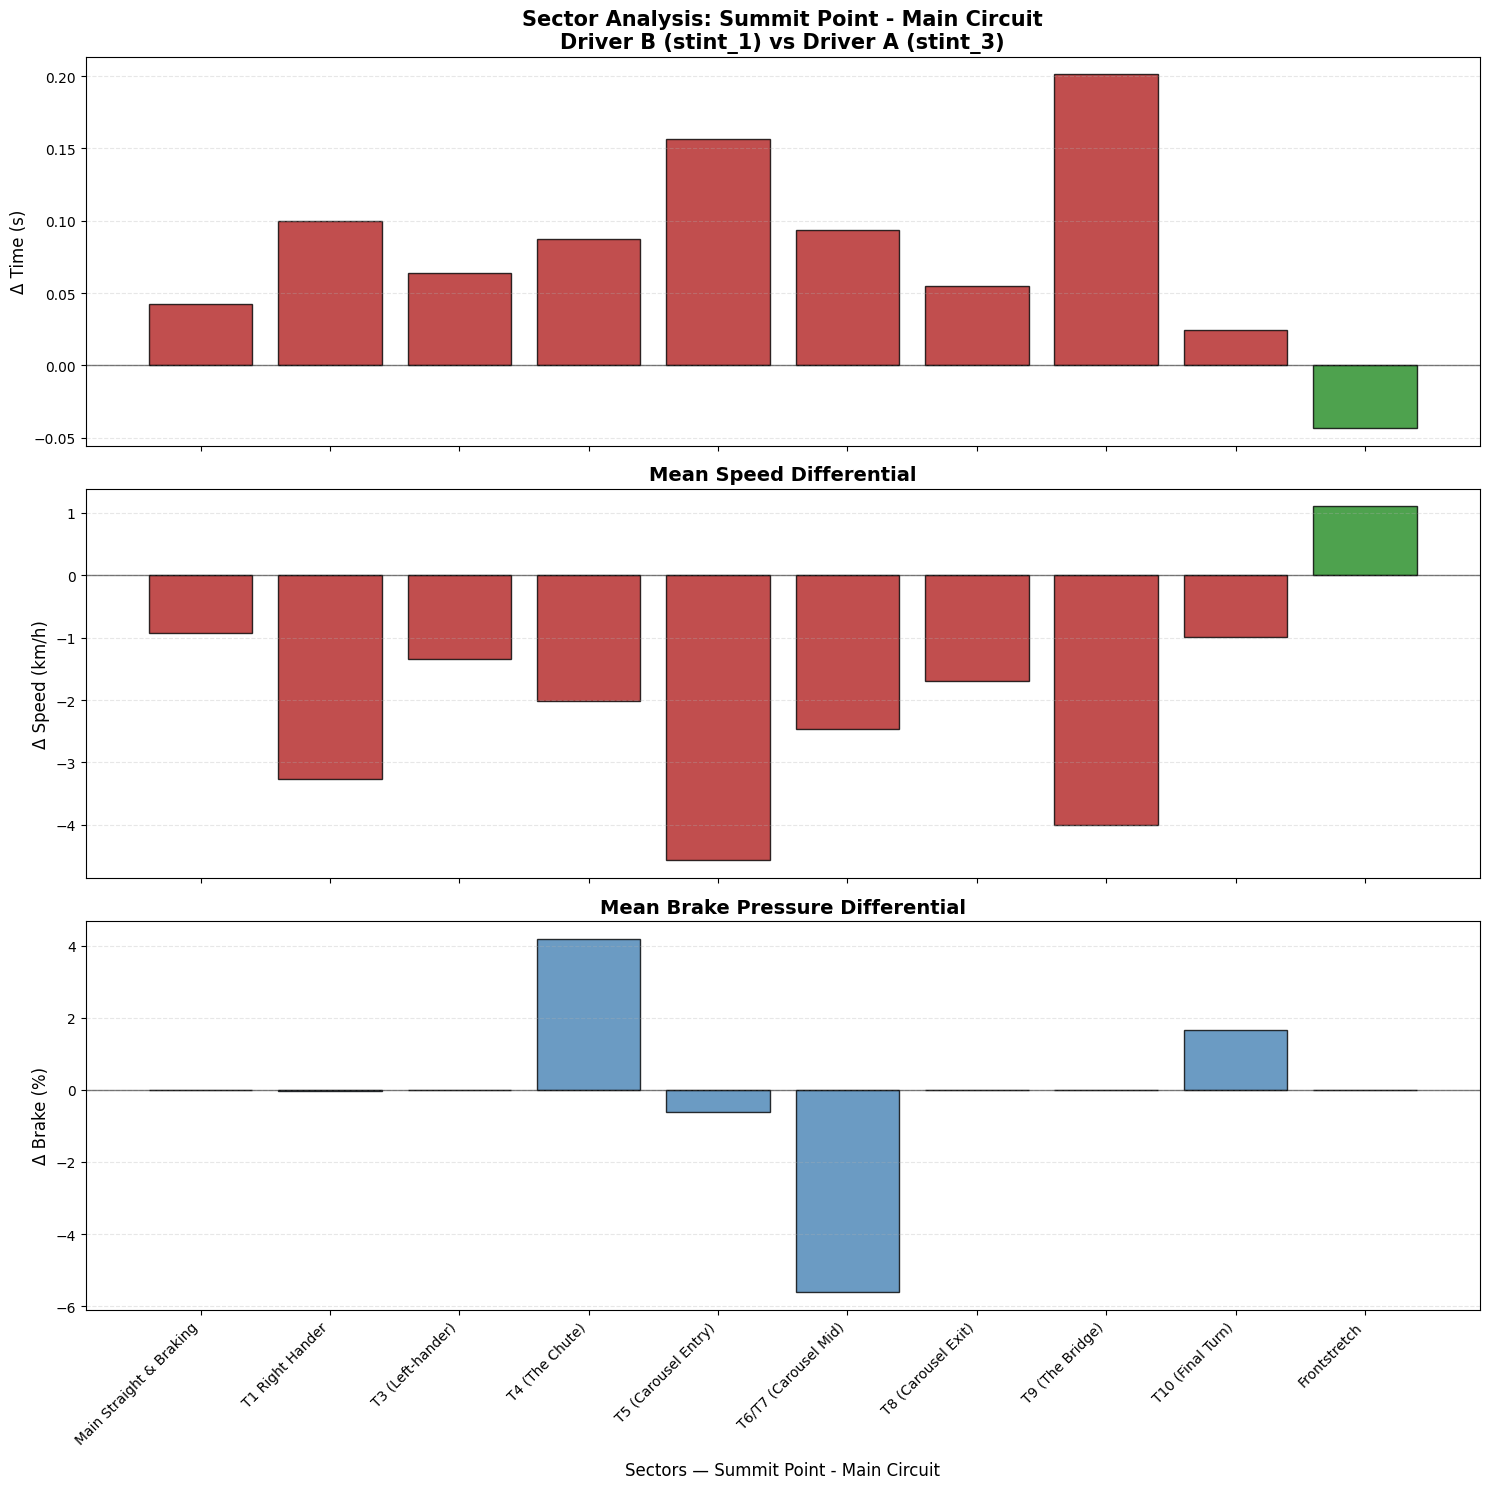

In [45]:
# --- 2. EXECUÇÃO DA ANÁLISE ---
sectors_AB = sector_analysis(
    interp_A,
    interp_B,
    edges=CUSTOM_EDGES,
    label_A=driver_a,
    label_B=driver_b,
)

sectors_AB["Turn"] = sectors_AB["Sector"].map(SECTOR_NAMES)
df_plot = sectors_AB.sort_values("Sector")

# --- 3. CONSTRUÇÃO DO DASHBOARD ---
fig, ax = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

# Gráfico 1: Delta de Tempo
colors_time = ['firebrick' if x > 0 else 'forestgreen' for x in df_plot["DeltaTime_s"]]
ax[0].bar(df_plot["Turn"], df_plot["DeltaTime_s"], color=colors_time, edgecolor='black', alpha=0.8)
ax[0].set_ylabel("Δ Time (s)", fontsize=12)
ax[0].set_title(
    f"Sector Analysis: {TRACK_NAME}\n{driver_b} ({STINT_TEST}) vs {driver_a} ({STINT_REF})",
    fontsize=15, fontweight='bold'
)
ax[0].axhline(0, color="black", linewidth=1, alpha=0.5)
ax[0].grid(axis='y', linestyle='--', alpha=0.3)

# Gráfico 2: Delta de Velocidade Média
colors_speed = ['forestgreen' if x > 0 else 'firebrick' for x in df_plot["MeanSpeedDiff_kph"]]
ax[1].bar(df_plot["Turn"], df_plot["MeanSpeedDiff_kph"], color=colors_speed, edgecolor='black', alpha=0.8)
ax[1].set_ylabel("Δ Speed (km/h)", fontsize=12)
ax[1].set_title("Mean Speed Differential", fontsize=14, fontweight='bold')
ax[1].axhline(0, color="black", linewidth=1, alpha=0.5)
ax[1].grid(axis='y', linestyle='--', alpha=0.3)

# Gráfico 3: Delta de Pressão de Freio
ax[2].bar(df_plot["Turn"], df_plot["MeanBrakeDiff_pct"], color='steelblue', edgecolor='black', alpha=0.8)
ax[2].set_ylabel("Δ Brake (%)", fontsize=12)
ax[2].set_title("Mean Brake Pressure Differential", fontsize=14, fontweight='bold')
ax[2].axhline(0, color="black", linewidth=1, alpha=0.5)
ax[2].grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.xlabel(f"Sectors — {TRACK_NAME}", fontsize=12, labelpad=10)
plt.tight_layout()

# --- 4. SALVAMENTO ---
file_name = f"sector_dashboard_{TRACK_NAME.replace(' ', '_').lower()}_{driver_a}_vs_{driver_b}.png"
save_path = SAVE_DIR / file_name

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()


## New Heuristics



## Base Functions 

In [46]:
from scipy.signal import savgol_filter
from typing import List

# --- Funções de Cálculo de Heurísticas (DNA) ---

def compute_derivatives(sec: dict):
    t = sec["t_rel"]
    # dt robusto para dados com pequena variação de amostragem
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01 

    brake = sec["brake"]
    throttle = sec["throttle"]

    # Cálculo da taxa de variação (Ramp Rates)
    brake_rate = np.gradient(brake, dt)
    throttle_rate = np.gradient(throttle, dt)

    # Suavização para remover ruído de sensor/input
    window = min(9, len(brake_rate))
    if window > 3 and window % 2 != 0:
        brake_rate = savgol_filter(brake_rate, window, 3)
        throttle_rate = savgol_filter(throttle_rate, window, 3)

    return brake_rate, throttle_rate

def braking_heuristics(sec: dict, brake_rate):
    d = {}
    brake_mask = sec["brake"] > 0.05
    if np.any(brake_mask):
        d["BrakeRampRate"] = float(np.quantile(brake_rate[brake_mask], 0.95))
        d["BrakeConsistency"] = float(np.var(brake_rate[brake_mask]))
        d["BrakeEfficiency"] = float(abs(np.min(sec["long_accel"][brake_mask])) / 
                                     (np.max(sec["brake"][brake_mask]) + 1e-6))
    else:
        d["BrakeRampRate"], d["BrakeConsistency"], d["BrakeEfficiency"] = 0.0, 0.0, 0.0
    return d

def rotation_heuristics(sec: dict):
    d = {}
    speed = sec["speed"]
    yaw = sec["yaw_rate"]
    steer = sec["steering"]
    t = sec["t_rel"]

    idx_vmin = np.argmin(speed)
    idx_mrp = np.argmax(np.abs(yaw))

    d["Vmin"] = float(speed[idx_vmin])
    d["Delta_MRP_Vmin"] = float(t[idx_vmin] - t[idx_mrp])
    
    # --- INJETADO: Trail Braking Overlap ---
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.01
    d["TrailOverlap"] = float((sec["brake"] * np.abs(steer) * dt).sum())
    
    # --- INJETADO: Vmin Normalizado (Eficiência de entrada) ---
    d["Vmin_Norm"] = float(d["Vmin"] / (speed[0] + 1e-6))

    avg_steer = np.mean(np.abs(steer))
    d["RotationEfficiency"] = float(np.mean(np.abs(yaw)) / (avg_steer + 1e-6)) if avg_steer > 1e-3 else 0.0
    return d

def acceleration_heuristics(sec: dict, throttle_rate):
    d = {}
    throttle_mask = sec["throttle"] > 0.05
    if np.any(throttle_mask):
        d["ThrottleAttackRate"] = float(np.quantile(throttle_rate[throttle_mask], 0.95))
        d["ThrottleSmoothness"] = float(1.0 / (np.var(throttle_rate[throttle_mask]) + 1e-6))
        d["ThrottleSteerConflict"] = float(np.mean(sec["throttle"] * np.abs(sec["steering"])))
        
        # --- INJETADO: Eficiência Longitudinal (G's por acelerador) ---
        d["AccelEfficiency"] = float(np.mean(sec["long_accel"][throttle_mask]) / 
                                     (np.mean(sec["throttle"][throttle_mask]) + 1e-6))
    else:
        d["ThrottleAttackRate"], d["ThrottleSmoothness"], d["ThrottleSteerConflict"], d["AccelEfficiency"] = 0.0, 0.0, 0.0, 0.0
    return d

def sector_heuristics(sec_raw: dict) -> dict:
    """Mapeia os canais brutos para o dicionário de heurísticas com métricas de memória."""
    sec = {
        "t_rel": sec_raw["t_rel"],
        "speed": sec_raw["speed"],
        "brake": sec_raw["brake"],
        "throttle": sec_raw["throttle"],
        "steering": sec_raw["SteeringWheelAngle"],
        "yaw_rate": sec_raw["YawRate"],
        "long_accel": sec_raw.get("LongAccel", np.zeros_like(sec_raw["speed"])),
    }

    brake_rate, throttle_rate = compute_derivatives(sec)

    # 1. Definimos as métricas de "fronteira" do setor (Essencial para o Legado)
    h = {
        "SpeedStart": float(sec["speed"][0]),
        "SpeedEnd": float(sec["speed"][-1]),
        "BrakePeak": float(np.max(sec["brake"])),  # Da sua função antiga
        "SteerRMS": float(np.sqrt(np.mean((sec["steering"])**2))) # Mede agressividade/sawing
    }

    # 2. Atualizamos com as heurísticas comportamentais
    h.update(braking_heuristics(sec, brake_rate))
    h.update(rotation_heuristics(sec))
    h.update(acceleration_heuristics(sec, throttle_rate))
    
    return h

# --- Função Principal Atualizada para ROval 2025 ---

def compute_sector_heuristics(interp, edges=CUSTOM_EDGES) -> pd.DataFrame:
    """
    Processa dados de telemetria (Dict ou DataFrame) corrigindo erros de ambiguidade
    e padronizando nomes de canais para o Doutorado.
    """
    # 1. Correção do erro de ambiguidade (The truth value of a DataFrame is ambiguous)
    if interp is None: return pd.DataFrame()
    if isinstance(interp, pd.DataFrame):
        if interp.empty: return pd.DataFrame()
    elif not interp: # Caso seja dicionário
        return pd.DataFrame()

    # 2. Padronização: se for DataFrame, precisamos garantir os nomes das colunas
    if isinstance(interp, pd.DataFrame):
        # Mapeia os nomes brutos do iRacing para os nomes que suas heurísticas usam
        mapping = {
            'Speed_KPH': 'speed', 
            'Throttle_Pct': 'throttle', 
            'Brake_Pct': 'brake',
            'SessionTime': 't_rel'
        }
        # Cria um dicionário de arrays para manter a lógica igual ao dicionário da 'interp'
        data_source = {mapping.get(c, c): interp[c].values for c in interp.columns}
        lap_dist = interp["LapDistPct"].values
    else:
        # Se já for o dicionário da align_lap_by_dist, usamos direto
        data_source = interp
        lap_dist = interp["LapDistPct"]

    rows = []

    # 3. Processamento por Setor
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i+1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size == 0: continue
            
        sl = slice(indices[0], indices[-1] + 1)
        
        # Filtra os dados do setor
        sec_raw = {k: v[sl] for k, v in data_source.items()}

        # Garante que t_rel comece em 0 para este setor específico (importante para derivadas)
        if "t_rel" in sec_raw:
            sec_raw["t_rel"] = sec_raw["t_rel"] - sec_raw["t_rel"][0]

        # Chama sua função de DNA técnico (sector_heuristics)
        h = sector_heuristics(sec_raw)

        sid = i + 1
        h_row = {"Sector": sid, "Turn": SECTOR_NAMES.get(sid, f"Sector {sid}")}
        h_row.update(h)
        rows.append(h_row)

    return pd.DataFrame(rows)

## Driver A and B - Heuristics

In [47]:
# --- Piloto A (Driver B) ---
# Substituímos n_sectors pelos marcos geográficos CUSTOM_EDGES
heur_A = compute_sector_heuristics(
    interp=interp_A,
    edges=CUSTOM_EDGES
)
heur_A.insert(0, "Pilot", "A")

# --- Piloto B (Driver C) ---
heur_B = compute_sector_heuristics(
    interp=interp_B,
    edges=CUSTOM_EDGES
)
heur_B.insert(0, "Pilot", "B")

# Exibição do resumo do Piloto B para conferência das curvas de 2025
display(heur_A)

,Pilot,Sector,Turn,SpeedStart,SpeedEnd,BrakePeak,SteerRMS,BrakeRampRate,BrakeConsistency,BrakeEfficiency,Vmin,Delta_MRP_Vmin,TrailOverlap,Vmin_Norm,RotationEfficiency,ThrottleAttackRate,ThrottleSmoothness,ThrottleSteerConflict,AccelEfficiency
0,A,1,Main Straight & Braking,182.132158,196.855038,0.000000,0.007976,0.000000,0.000000,0.000000,182.132158,-6.278288,0.000000,1.000000,0.767290,0.000000,1000000.000000,0.611091,0.005765
1,A,2,T1 Right Hander,196.901376,120.582599,91.805960,0.605261,161.032984,4613.361536,0.144889,81.822644,0.211754,49.308549,0.415551,0.571239,55.989561,0.000128,24.261475,0.009830
2,A,3,T3 (Left-hander),120.965186,167.187794,0.000000,0.098985,0.000000,0.000000,0.000000,120.965186,-0.143857,0.000000,1.000000,0.914256,0.000000,0.001105,7.826191,0.016365
3,A,4,T4 (The Chute),167.247662,162.304251,9.364947,0.449084,44.987255,867.109190,0.361747,143.492644,-0.277670,1.023228,0.857965,0.612522,90.249368,0.000108,16.725523,0.012392
4,A,5,T5 (Carousel Entry),162.499136,168.857876,62.845523,0.353116,221.036737,3601.583821,0.143010,162.499136,-4.282657,1.635965,1.000000,0.628484,96.907229,0.000117,18.946676,0.005830
5,A,6,T6/T7 (Carousel Mid),167.814075,89.545789,80.066723,0.879507,44.687973,1696.543313,0.137496,73.583910,0.606520,107.958773,0.438485,0.568472,273.363244,0.000070,34.492059,0.018737
6,A,7,T8 (Carousel Exit),90.150379,143.702048,0.000000,0.496549,0.000000,0.000000,0.000000,90.150379,-3.696840,0.000000,1.000000,0.768636,0.000000,1000000.000000,46.439223,0.022088
7,A,8,T9 (The Bridge),143.886597,171.482026,0.000000,0.261926,0.000000,0.000000,0.000000,143.886597,-3.211044,0.000000,1.000000,0.810083,0.000000,1000000.000000,18.849261,0.013387
8,A,9,T10 (Final Turn),171.607740,158.287476,39.640176,0.452927,126.798146,3107.528809,0.172982,145.358602,0.079532,6.304910,0.847040,0.550169,71.915061,0.000128,16.652050,0.009159
9,A,10,Frontstretch,158.443640,180.773163,0.000000,0.016725,0.000000,0.000000,0.000000,158.443640,-0.969693,0.000000,1.000000,0.920817,0.000000,1000000.000000,1.183508,0.010570


# Feature Engineering

Esta seção implementa um pipeline de *coaching* baseado em regras para comparar duas voltas (A como referência e B como piloto avaliado) **por setor**. O objetivo é transformar séries temporais brutas (speed, brake, throttle, steering, yaw, RPM e gear) em:

1. **Estados interpretáveis** ao longo da volta (BRAKING, CORNER, EXIT, STRAIGHT).
2. **Métricas agregadas** por (Setor, Estado), permitindo comparação entre A e B.
3. **Deltas (B − A)** por métrica, para localizar onde o piloto perde tempo.
4. **Regras de feedback** que geram dicas curtas e acionáveis, com contexto de *onde* e *que tipo de curva* é.

A ideia central é reduzir a complexidade do sinal contínuo para um conjunto pequeno de indicadores por fase de pilotagem, o que facilita feedback para pilotos iniciantes e permite evolução incremental das regras ao longo do tempo.

## Utilitários de índice (primeiro e último evento)

Antes de extrair eventos (por exemplo, início e fim de frenagem), usamos dois utilitários simples:

- `_first_idx(mask)`: retorna o primeiro índice onde uma condição booleana é verdadeira.
- `_last_idx(mask)`: retorna o último índice onde uma condição booleana é verdadeira.

Essas funções são úteis para detectar “janelas de evento” em sinais contínuos, como:
- intervalo em que o freio está acima de um threshold;
- intervalo em que o throttle está acima de um threshold após o ápice;
- overlap entre freio e acelerador.

Esse padrão evita lógica repetida e padroniza o comportamento quando o evento não existe (retorna `None`).

In [48]:
def _first_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[0]) if idx.size else None

def _last_idx(mask: np.ndarray):
    idx = np.flatnonzero(mask)
    return int(idx[-1]) if idx.size else None

## Rotulagem de estados (BRAKING, CORNER, EXIT, STRAIGHT)

Para gerar dicas por fase, primeiro precisamos “entender” o que o carro está fazendo ao longo do tempo. A função `label_state_df` recebe um DataFrame com sinais normalizados em percentual e devolve um vetor de estados:

- **BRAKING**: freio acima do threshold.
- **CORNER**: lateralidade alta (steering e opcionalmente yaw), independentemente do throttle.
- **EXIT**: throttle alto **e** lateralidade baixa (carro já está alinhado).
- **STRAIGHT**: restante.

A ordem de prioridade é importante:

1. **BRAKING tem prioridade máxima**, porque durante a frenagem o comportamento é dominado pela desaceleração e estabilidade.
2. **CORNER vem em seguida**, para capturar curvas “flat-out” (throttle alto com volante carregado).
3. **EXIT só ocorre quando o carro está alinhado**, ou seja, throttle alto com baixa lateralidade, representando retomada na saída.
4. O que sobra vira **STRAIGHT**.

Esse esquema evita confundir “aceleração em curva” com “saída da curva” e produz estados mais coerentes para coaching.

In [49]:
import numpy as np
import pandas as pd

## Não utilizado nesta análise, mas mantido para referência futura ##
def label_state_df(
    g: pd.DataFrame,
    brake_th: float = 15.0,
    throttle_th: float = 60.0,
    steer_th: float = 1.0,        # 👈 menor
    latacc_th: float = 0.6,       # g lateral
    window: int = 15              # suavização
):
    """
    Estados:
    BRAKING / CORNER / EXIT / STRAIGHT

    Filosofia:
    - CORNER = lateral sustentada (não pico de volante)
    - EXIT = transição curta pós-curva
    - STRAIGHT = WOT estável
    """

    brake = g["Brake_Pct"].to_numpy()
    throttle = g["Throttle_Pct"].to_numpy()
    speed = g["Speed_KPH"].to_numpy()
    steer = g["SteeringWheelAngle"].to_numpy()

    latacc = (
        g["LatAccel"].to_numpy()
        if "LatAccel" in g.columns
        else np.zeros(len(g))
    )

    n = len(g)
    state = np.array(["STRAIGHT"] * n, dtype=object)

    # =========================
    # 1) BRAKING
    # =========================
    braking = brake > brake_th
    state[braking] = "BRAKING"

    # =========================
    # 2) CORNER (lateral sustentada)
    # =========================
    steer_rms = pd.Series(steer).rolling(
        window, center=True, min_periods=5
    ).std().to_numpy()

    lateral = (
        (np.abs(latacc) > latacc_th) |
        (steer_rms > steer_th)
    )

    corner = lateral & (~braking)
    state[corner] = "CORNER"

    # =========================
    # 3) EXIT (curta transição)
    # =========================
    d_speed = np.gradient(speed)

    exit_mask = (
        (throttle > throttle_th) &
        (~braking) &
        (~corner) &
        (d_speed > 0.05)
    )

    state[exit_mask] = "EXIT"

    # =========================
    # 4) STRAIGHT (estável)
    # =========================
    straight = (
        (throttle > 90) &
        (~braking) &
        (~corner) &
        (steer_rms < steer_th * 0.6) &
        (np.abs(latacc) < latacc_th * 0.7)
    )

    return pd.Series(state, index=g.index, name="State")


## Agregação por (Setor, Estado)

Após rotular cada amostra com um estado, a função `summarize_by_sector_and_state` transforma a volta em uma tabela agregada. O procedimento é:

1. **Divide a volta em setores** usando `LapDistPct` em intervalos uniformes (ex.: 4 setores por quartis).
2. **Cria um DataFrame temporário (`gtmp`)** com as colunas exigidas por `label_state_df`, reaproveitando a mesma assinatura.
3. **Gera o vetor de estados** para cada amostra.
4. **Segmenta trechos contínuos** com o mesmo estado (runs).  
   - Isso evita misturar momentos diferentes da pilotagem dentro do mesmo estado.
   - `min_len` remove segmentos muito curtos, que tendem a ser ruído de limiar.
5. Para cada segmento válido, calcula métricas relevantes e monta linhas “por trecho”.
6. Por fim, agrega (groupby) por **(Sector, State)** para obter uma tabela compacta por volta.

O resultado é uma tabela que representa “como foi a pilotagem em cada setor e em cada fase”, pronta para comparação entre A e B.

In [50]:
import numpy as np
import pandas as pd
from collections import Counter

def summarize_by_sector_and_state(interp: dict, edges=CUSTOM_EDGES, min_len=5):
    """
    Agrupa a telemetria por Curvas Reais e Estados de Condução, 
    incluindo a detecção do ponto de início de frenagem.
    """
    # 1. Extração de dados
    lap = interp["LapDistPct"]
    speed = interp["speed"]
    brake = interp["brake"]
    throttle = interp["throttle"]
    steer = interp.get("SteeringWheelAngle", np.zeros_like(speed))
    latacc = interp.get("LatAccel", np.zeros_like(speed))

    # 2. Setorização por Marcos Geográficos (Curvas)
    sector = np.clip(np.digitize(lap, edges, right=True), 1, len(edges)-1)

    # 3. Classificação de Estados
    gtmp = pd.DataFrame({
        "Brake_Pct": brake, "Throttle_Pct": throttle,
        "Speed_KPH": speed, "LatAccel": latacc, "SteeringWheelAngle": steer
    })
    
    # Assume que label_state_df está definida globalmente
    state = label_state_df(gtmp).to_numpy()

    def segment_runs(vals):
        runs = []
        n = len(vals); i = 0
        while i < n:
            j = i + 1
            while j < n and vals[j] == vals[i]: j += 1
            runs.append((i, j, vals[i]))
            i = j
        return runs

    # 4. Processamento de Heurísticas
    rows = []
    for a, b, lab in segment_runs(state):
        if (b - a) < min_len: continue

        sid = int(Counter(sector[a:b].tolist()).most_common(1)[0][0])
        
        # --- FEATURE ENGINEERING: Ponto de Início de Frenagem ---
        # Se o estado for 'Braking', registramos a posição exata de início (lap[a])
        # Ajuste o nome da string 'Braking' se o seu label_state_df usar outro termo
        brake_start = float(lap[a]) if "Braking" in str(lab) else np.nan
        
        row = {
            "Sector": sid, 
            "State": lab, 
            "Len": int(b - a),
            "SpeedMean": float(np.mean(speed[a:b])),
            "Vmin": float(np.min(speed[a:b])),
            "ThrottleMean": float(np.mean(throttle[a:b])),
            "BrakePeak": float(np.max(brake[a:b])),
            "BrakeStartDist": brake_start, # Nova métrica
            "SteerRMS": float(np.sqrt(np.mean((steer[a:b])**2))),
            "EntrySpeed": float(speed[a]) 
        }
        rows.append(row)

    seg_df = pd.DataFrame(rows)
    if seg_df.empty: return seg_df

    # 5. Agregação Final
    # Usamos 'min' para BrakeStartDist para pegar o ponto mais precoce de frenagem no setor
    agg = seg_df.groupby(["Sector", "State"], as_index=False).agg({
        "SpeedMean": "mean",
        "Vmin": "mean",
        "ThrottleMean": "mean",
        "BrakePeak": "max",
        "BrakeStartDist": "min", 
        "SteerRMS": "mean",
        "EntrySpeed": "mean"
    })
    return agg

def generate_dna_comparison(df_a, df_b):
    """
    Cria a tabela comparativa de DNA de Pilotagem com métricas de posicionamento espacial.
    """
    # Merge das tabelas dos dois pilotos
    m = pd.merge(df_a, df_b, on=["Sector", "State"], suffixes=("_A", "_B"))
    
    # Adiciona nomes das curvas (assume que SECTOR_NAMES existe)
    m["Turn_Name"] = m["Sector"].map(SECTOR_NAMES)
    
    # Lista atualizada de métricas para comparação
    metrics = ["Vmin", "BrakePeak", "EntrySpeed", "SteerRMS", "BrakeStartDist"]
    
    for col in metrics:
        if f"{col}_A" in m.columns and f"{col}_B" in m.columns:
            m[f"Delta_{col}"] = m[f"{col}_B"] - m[f"{col}_A"]

    # Reorganiza colunas para o relatório final
    cols = ["Sector", "Turn_Name", "State"] + [f"Delta_{c}" for c in metrics]
    return m.sort_values(by=["Sector", "State"])

In [51]:
def compare_pilot_heuristics_per_turn(heur_A, heur_B):
    """
    Une as heurísticas dos dois pilotos em uma única tabela de 18 linhas,
    calculando os deltas técnicos para cada curva.
    """
    # 1. Merge das tabelas (A e B já calculadas por compute_sector_heuristics)
    # Cada tabela já possui 18 linhas (uma por curva do Roval 2025)
    m = pd.merge(heur_A, heur_B, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Identifica automaticamente as colunas de métricas para calcular Delta
    # Remove colunas de identificação
    excluded = ["Pilot_A", "Pilot_B", "Sector", "Turn"]
    metrics = [c.replace("_A", "") for c in m.columns if c.endswith("_A") and c not in excluded]
    
    for col in metrics:
        col_a = f"{col}_A"
        col_b = f"{col}_B"
        # Delta = Driver C (B) - Driver B (A)
        m[f"Δ_{col}"] = m[col_b] - m[col_a]
        
    return m.sort_values("Sector")

# --- EXECUÇÃO ---
# 1. Calcula as heurísticas completas para os 18 setores
hA = compute_sector_heuristics(interp_A, edges=CUSTOM_EDGES)
hB = compute_sector_heuristics(interp_B, edges=CUSTOM_EDGES)

# 2. Gera a comparação final (Sem a divisão por estados)
dna_turns = compare_pilot_heuristics_per_turn(hA, hB)

# 3. Exibição
display(dna_turns.head())

,Sector,Turn,SpeedStart_A,SpeedEnd_A,BrakePeak_A,SteerRMS_A,BrakeRampRate_A,BrakeConsistency_A,BrakeEfficiency_A,Vmin_A,...,Δ_BrakeEfficiency,Δ_Vmin,Δ_Delta_MRP_Vmin,Δ_TrailOverlap,Δ_Vmin_Norm,Δ_RotationEfficiency,Δ_ThrottleAttackRate,Δ_ThrottleSmoothness,Δ_ThrottleSteerConflict,Δ_AccelEfficiency
0,1,Main Straight & Braking,182.132158,196.855038,0.000000,0.007976,0.000000,0.000000,0.000000,182.132158,...,0.000000,-1.370778,4.866936,0.000000,-4.163647e-11,0.117440,0.000000,0.000000,0.324019,0.000543
1,2,T1 Right Hander,196.901376,120.582599,91.805960,0.605261,161.032984,4613.361536,0.144889,81.822644,...,-0.000122,-0.571781,-0.141549,0.790520,-1.654999e-03,-0.091611,67.110583,-0.000019,5.096538,0.002437
2,3,T3 (Left-hander),120.965186,167.187794,0.000000,0.098985,0.000000,0.000000,0.000000,120.965186,...,0.000000,-1.573552,-1.719947,0.000000,-1.089550e-10,-0.084236,0.000000,999999.998895,1.366916,0.000349
3,4,T4 (The Chute),167.247662,162.304251,9.364947,0.449084,44.987255,867.109190,0.361747,143.492644,...,-0.203725,-1.490531,-0.557666,7.244168,-3.446068e-03,0.122419,73.562347,0.000018,2.671065,0.000288
4,5,T5 (Carousel Entry),162.499136,168.857876,62.845523,0.353116,221.036737,3601.583821,0.143010,162.499136,...,0.000054,-5.993724,5.225945,-0.574183,-3.146827e-02,-0.028557,-23.784020,0.000048,-6.954123,-0.005056


## Geração das tabelas agregadas (A e B)

Com `summarize_by_sector_and_state`, geramos uma tabela por volta:

- `A_seg`: volta de referência (lap A)
- `B_seg`: volta do piloto avaliado (lap B)

Cada tabela contém linhas por (Setor, Estado) e colunas com as métricas agregadas.  
Essas tabelas são a base do passo seguinte: comparar A vs B e calcular deltas.

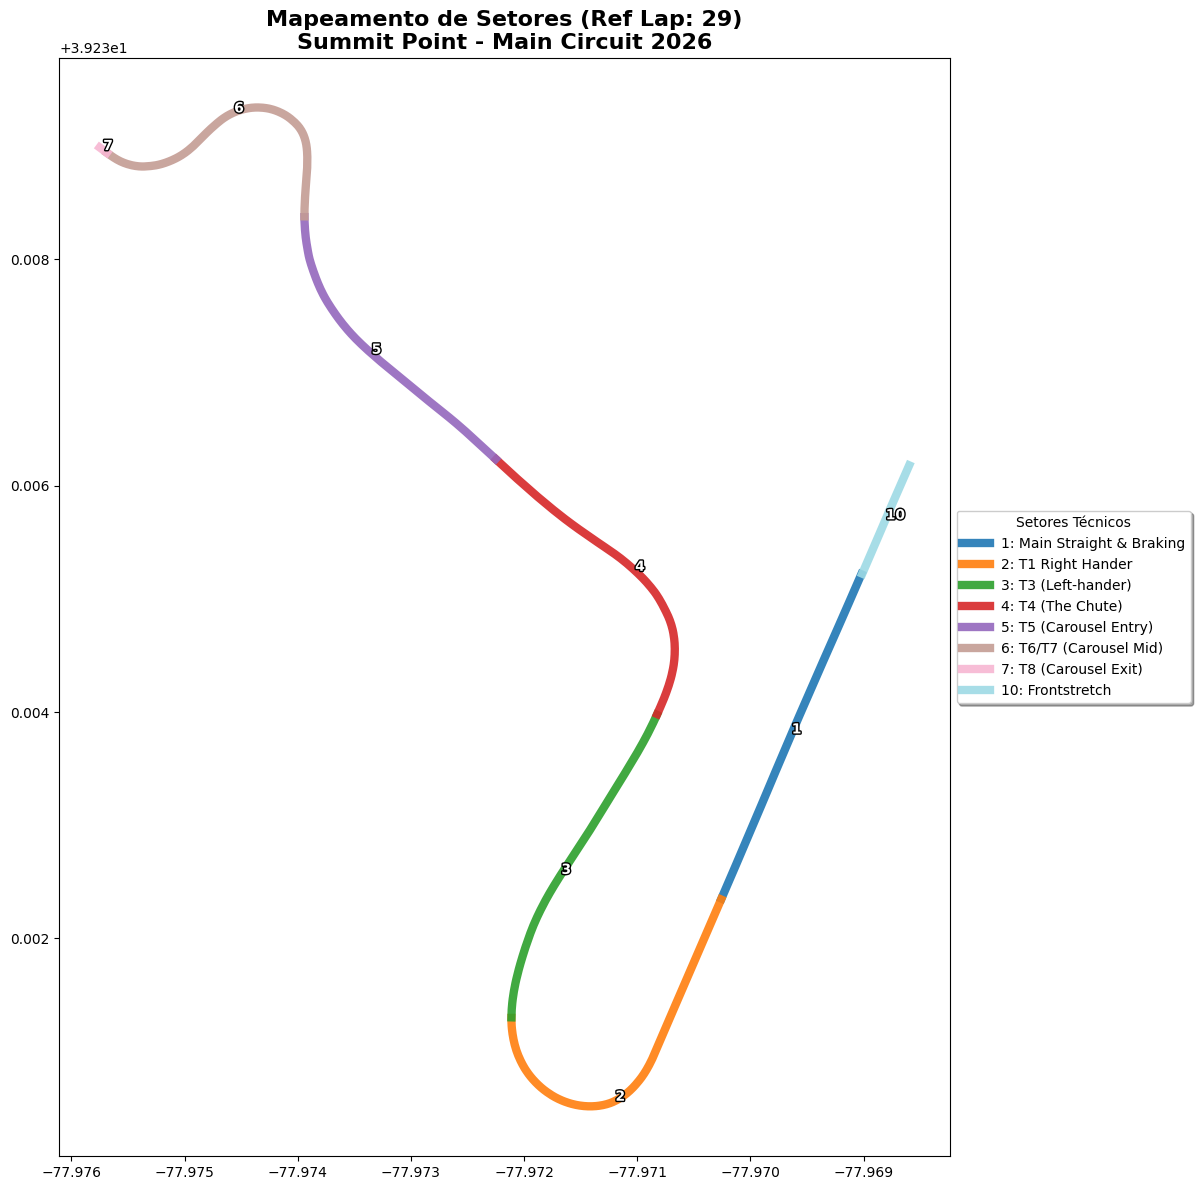

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import numpy as np
import os

def plot_and_save_sectors(df, track_name="Summit Point", edges=CUSTOM_EDGES, names=SECTOR_NAMES):
    # 1. Identificação Automática da Volta Mais Rápida
    lap_stats = df.groupby("Lap")["SessionTime"].agg(lambda x: x.max() - x.min())
    valid_laps = lap_stats[lap_stats > 30] 
    ref_lap = valid_laps.idxmin()
    
    # 2. Preparação dos Dados
    g = df[df["Lap"] == ref_lap].copy().sort_values("SessionTime")
    if g["LapDistPct"].max() > 1.5:
        g["LapDistPct"] /= 100.0
        
    g["Sector"] = np.clip(np.digitize(g["LapDistPct"], edges, right=True), 1, len(edges)-1)
    
    # 3. Configuração do Mapa
    fig, ax = plt.subplots(figsize=(15, 12))
    cmap = plt.get_cmap('tab20', len(edges)-1)
    
    for sid in sorted(g["Sector"].unique()):
        sector_data = g[g["Sector"] == sid]
        if sector_data.empty: continue
        
        ax.plot(sector_data["Lon"], sector_data["Lat"], 
                color=cmap(sid-1), lw=6, alpha=0.9, 
                label=f"{sid}: {names.get(sid, 'Setor')}")
        
        mid_idx = len(sector_data) // 2
        ax.text(sector_data["Lon"].iloc[mid_idx], sector_data["Lat"].iloc[mid_idx], 
                str(sid), fontsize=10, weight='bold', color='white',
                path_effects=[patheffects.withStroke(linewidth=2, foreground="black")])

    # 4. Estética e Título Dinâmico
    ax.set_aspect('equal')
    ax.set_title(f"Mapeamento de Setores (Ref Lap: {ref_lap})\n{track_name} 2026", 
                 fontsize=16, fontweight='bold')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Setores Técnicos", 
              fontsize=10, shadow=True, fancybox=True)
    
    plt.tight_layout()

        
    return fig, ax

# --- EXECUÇÃO PARA SUMMIT POINT ---
fig, ax = plot_and_save_sectors(df_ref, track_name=TRACK_NAME)
plt.show()

## Comparação A vs B por estado e setor (deltas B − A)

A função `compare_seg_tables` faz o merge das tabelas agregadas por:

- `Sector`
- `State`

e cria colunas `Δ_*` calculadas como **B − A** para cada métrica existente.

Por que usar deltas?

- As métricas absolutas variam por carro, setup e pista.
- O delta foca no que importa para coaching: **o que mudou em relação à referência**.
- Os deltas viram “features” de regras: exemplos
  - Δ_EntrySpeed negativo → piloto entra mais lento.
  - Δ_ThrottleOn_Speed negativo → piloto retoma com velocidade menor.
  - Δ_CoastFrac positivo → piloto está “tirando pé” mais tempo.

Além das métricas agregadas, também existe espaço para incluir colunas do pipeline 1 (como BrakeRampRate etc.), quando elas estiverem disponíveis em `A_seg` e `B_seg`.

In [53]:
def generate_master_comparison(heur_A, heur_B):
    """
    Versão otimizada da compare_seg_tables para análise por curva (sem States).
    Une os pilotos A e B e calcula deltas de todas as métricas.
    """
    # 1. Cruzamento apenas por Setor e Nome da Curva
    # (Removido o "State" para bater com sua nova filosofia de análise)
    m = pd.merge(heur_A, heur_B, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Identifica automaticamente as métricas (tudo que termina em _A)
    # Isso evita que você tenha que listar 50 nomes de colunas manualmente
    metrics = [c.replace("_A", "") for c in m.columns if c.endswith("_A") and c not in ["Pilot_A", "Turn_A"]]
    
    for col in metrics:
        col_a, col_b = f"{col}_A", f"{col}_B"
        if col_a in m.columns and col_b in m.columns:
            # Cálculo do Delta: B (Driver C) - A (Driver B)
            m[f"Δ_{col}"] = m[col_b] - m[col_a]
            
    return m.sort_values("Sector").reset_index(drop=True)

# --- COMO USAR AGORA ---
# 1. Gere as tabelas de 18 linhas para cada piloto
hA = compute_sector_heuristics(interp_A, edges=CUSTOM_EDGES)
hB = compute_sector_heuristics(interp_B, edges=CUSTOM_EDGES)

# 2. Crie a Master Table com os Deltas
seg_cmp = generate_master_comparison(hA, hB)

# 3. Verifique a estrutura (as 55 colunas estarão lá)
#seg_cmp.info()

## Extração de eventos por setor (apex e timings)

Além da visão por estado, usamos um segundo bloco para extrair eventos “pontuais” dentro de cada setor, como:

- **Vmin**: proxy do ápice (mínima velocidade do setor).
- **brake_on / brake_off**: início/fim da janela de freio acima do threshold.
- **throttle_on**: primeiro ponto de throttle acima do threshold após o ápice.

Com esses eventos calculamos métricas temporais relativas ao ápice (Vmin), como:

- **brake_lead_vs_vmin**: quanto antes do ápice o freio começa.
- **brake_release_vs_vmin**: quanto depois/antes do ápice o freio termina.
- **throttle_delay_vs_vmin**: quanto tempo após o ápice o throttle volta.

Esse conjunto é útil para regras mais “cinemáticas” (timing), complementando as métricas agregadas por estado.

In [54]:
def sector_events(sec, brake_th=0.05, throttle_th=0.05):
    t = sec["t_rel"]
    speed = sec["speed"]
    brake = sec["brake"]
    throttle = sec["throttle"]
    lap = sec["LapDistPct"]

    idx_vmin = int(np.argmin(speed))

    # brake_on/off: primeiro e último acima do threshold (dentro do setor)
    brake_mask = brake > brake_th
    idx_brake_on = _first_idx(brake_mask)
    idx_brake_off = _last_idx(brake_mask)

    # throttle_on: primeiro throttle após o vmin
    post = np.arange(len(t)) >= idx_vmin
    idx_throttle_on = _first_idx((throttle > throttle_th) & post)

    ev = {
        "t_vmin": float(t[idx_vmin]),
        "vmin": float(speed[idx_vmin]),
        "lap_vmin": float(lap[idx_vmin]) if lap is not None else None,

        "t_brake_on": float(t[idx_brake_on]) if idx_brake_on is not None else None,
        "t_brake_off": float(t[idx_brake_off]) if idx_brake_off is not None else None,

        "t_throttle_on": float(t[idx_throttle_on]) if idx_throttle_on is not None else None,
    }

    # relações ao apex (Vmin)
    ev["brake_lead_vs_vmin"] = (ev["t_vmin"] - ev["t_brake_on"]) if ev["t_brake_on"] is not None else None
    ev["throttle_delay_vs_vmin"] = (ev["t_throttle_on"] - ev["t_vmin"]) if ev["t_throttle_on"] is not None else None
    ev["brake_release_vs_vmin"] = (ev["t_brake_off"] - ev["t_vmin"]) if ev["t_brake_off"] is not None else None

    return ev

def compute_sector_events_table(interp, edges=CUSTOM_EDGES):
    """
    Versão atualizada: Extrai o TIMING de cada ação para as 18 curvas reais.
    """
    lap_dist = interp["LapDistPct"]
    rows = []
    
    # Criamos as fatias baseadas nos marcos geográficos das curvas
    for i in range(len(edges) - 1):
        mask = (lap_dist >= edges[i]) & (lap_dist < edges[i+1])
        if i == len(edges) - 2:
            mask = (lap_dist >= edges[i]) & (lap_dist <= edges[i+1])
            
        indices = np.flatnonzero(mask)
        if indices.size == 0: continue
            
        sl = slice(indices[0], indices[-1] + 1)
        sec = {k: v[sl] for k, v in interp.items()}
        sec["LapDistPct"] = interp["LapDistPct"][sl]
        
        # Chama a função que identifica o momento exato de cada evento
        ev = sector_events(sec)

        sid = i + 1
        row = {
            "Sector": sid, 
            "Turn": SECTOR_NAMES.get(sid, f"S{sid}"),
            **ev
        }
        rows.append(row)

    return pd.DataFrame(rows)

## Tabela de eventos por setor

`compute_sector_events_table` percorre todos os setores e aplica `sector_events` para cada slice da volta.

O resultado é uma tabela por volta (A e B) com:
- posição do ápice (lap_vmin),
- timings (t_brake_on/off, t_throttle_on),
- métricas relativas ao ápice.

Depois, `compare_sector_tables` faz o merge A vs B por setor e produz `Δ_*` das métricas principais.

Essa tabela é usada para detectar padrões de “timing”, como:
- frear cedo demais,
- soltar freio tarde demais,
- voltar ao throttle tarde demais.

In [55]:
def compare_sector_timing(evA, evB, sectors_AB):
    """
    Une os eventos de timing e correlaciona com o ganho/perda de tempo.
    """
    # 1. Merge dos eventos de timing (A e B)
    # Incluímos 'Turn' no merge para manter os nomes das curvas do Roval 2025
    m = evA.merge(evB, on=["Sector", "Turn"], suffixes=("_A", "_B"))
    
    # 2. Trazemos o DeltaTime_s (a performance final de cada setor)
    m = m.merge(sectors_AB[["Sector", "DeltaTime_s"]], on="Sector", how="left")

    # 3. Cálculo dos Deltas de Timing (B - A)
    # Valores negativos em brake_lead significam que B freou mais tarde
    # Valores positivos em throttle_delay significam que B demorou mais para acelerar
    timing_metrics = ["vmin", "brake_lead_vs_vmin", "throttle_delay_vs_vmin", "brake_release_vs_vmin"]
    
    for c in timing_metrics:
        if f"{c}_A" in m.columns and f"{c}_B" in m.columns:
            m[f"Δ_{c}"] = m[f"{c}_B"] - m[f"{c}_A"]

    return m.sort_values("Sector")

# --- EXECUÇÃO ATUALIZADA ---
# Chamando as funções com CUSTOM_EDGES em vez de N_SECTORS
evA = compute_sector_events_table(interp_A, edges=CUSTOM_EDGES)
evB = compute_sector_events_table(interp_B, edges=CUSTOM_EDGES)

# Gerando a tabela comparativa de timing
ev_cmp = compare_sector_timing(evA, evB, sectors_AB)

#display(ev_cmp)

## Contexto textual da dica: posição no setor e tipo de curva (proxy)

Para que a mensagem de coaching seja mais compreensível, adicionamos um prefixo com:

1. **Setor** (S1..Sn).
2. **Posição no setor**: início, meio ou fim (derivado de LapDistPct relativo ao intervalo do setor).
3. **Tipo de curva**: reta/aberta, média ou fechada.

O tipo de curva é estimado por um proxy geométrico:
- mede picos locais de yaw e steer em uma janela “à frente” do evento,
- transforma o valor em percentil dentro de uma distribuição construída ao longo da volta,
- classifica em níveis (aberta/média/fechada).

A motivação é prática: pilotos iniciantes entendem melhor “onde” e “que tipo de curva” do que apenas uma métrica abstrata.

In [56]:
def sector_position_label(lap_pct: float, sector_id: int, edges=CUSTOM_EDGES) -> str:
    """Usa as bordas reais para definir início/meio/fim da curva."""
    if not np.isfinite(lap_pct) or sector_id > len(edges)-1:
        return "posição indefinida"
    
    s0 = edges[sector_id - 1]
    s1 = edges[sector_id]
    
    # Cálculo da posição relativa dentro da curva real
    # u = (lap_pct - s0) / (s1 - s0)
    u = (lap_pct - s0) / (s1 - s0 + 1e-12)
    
    if u < 0.33: return "entrada" # Início da curva/setor
    if u < 0.66: return "ápice"   # Meio da curva/setor
    return "saída"               # Fim da curva/setor

def peak_proxy_ahead(interp: dict, lap_pct: float, ahead_pct: float = 0.02, window_pct: float = 0.004):
    """
    Retorna o pico de curvatura e pico de steer em uma janela [lap, lap+ahead].
    - ahead_pct=0.02 => olha até +2% da volta (ótimo para pegar a curva depois da frenagem)
    """
    lap = interp.get("LapDistPct", None)
    if lap is None or not np.isfinite(lap_pct):
        return np.nan, np.nan

    lap = np.asarray(lap)

    # máscara lookahead (sem wrap-around por enquanto; suficiente pra dentro do setor)
   # Adicione o operador de módulo % 1.0 para lidar com a virada da volta
    m = (lap >= (lap_pct - window_pct) % 1.0) & (lap <= (lap_pct + ahead_pct) % 1.0)
    if not np.any(m):
        return np.nan, np.nan

    speed = np.asarray(interp.get("speed", np.nan*np.ones_like(lap)))

    # yaw proxy
    yaw_peak = np.nan
    if interp.get("YawRate", None) is not None:
        yaw = np.asarray(interp["YawRate"])
        v_ms = speed[m] / 3.6
        valid = (v_ms > 2.0) & np.isfinite(yaw[m]) & np.isfinite(v_ms)
        if np.any(valid):
            vals = np.abs(yaw[m][valid]) / (v_ms[valid] + 1e-6)
            yaw_peak = float(np.nanmax(vals))

    # steer proxy
    steer_peak = np.nan
    if interp.get("SteeringWheelAngle", None) is not None:
        steer = np.asarray(interp["SteeringWheelAngle"])
        vals = np.abs(steer[m])
        vals = vals[np.isfinite(vals)]
        if vals.size:
            steer_peak = float(np.nanmax(vals))

    return yaw_peak, steer_peak

def build_proxy_distributions(interp: dict):
    sample_pcts = np.linspace(0.01, 0.99, 250)
    yaw_vals, st_vals = [], []
    for p in sample_pcts:
        ypk, spk = peak_proxy_ahead(interp, p, ahead_pct=0.02, window_pct=0.003)
        if np.isfinite(ypk): yaw_vals.append(ypk)
        if np.isfinite(spk): st_vals.append(spk)
    return np.sort(np.asarray(yaw_vals)), np.sort(np.asarray(st_vals))

def percentile_rank(sorted_vals: np.ndarray, x: float) -> float:
    if sorted_vals.size == 0 or not np.isfinite(x):
        return np.nan
    return float(np.searchsorted(sorted_vals, x, side="right") / sorted_vals.size)

def label_from_percentile(p: float) -> str:
    if not np.isfinite(p):
        return "geometria indefinida"
    if p >= 0.80:
        return "curva fechada"
    if p >= 0.55:
        return "curva média"
    return "reta ou curva aberta"

def pick_event_lappct(row: pd.Series, state: str) -> float:
    """Escolhe o LapPct onde a dica realmente acontece (âncora do texto)."""
    if state == "EXIT":
        v = row.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    if state == "BRAKING":
        v = row.get("BrakePeak_Lap_B", np.nan)
        if np.isfinite(v):
            return float(v)
    return float(row.get("LapMid_B", np.nan))


def pick_geometry_lappct(row_dict: dict, state: str, rule_id: str = "") -> float:
    """
    Onde medir a geometria:
    - BRAKING: olhar adiante do pico de freio (pegar curva após a frenagem)
    - EXIT:
        * se a dica é de 'saída limitada' (linha/ápice), medir mais perto do miolo (LapMid)
        * se a dica é de gear/rpm, medir perto do throttle-on
    """
    if state == "BRAKING":
        p = row_dict.get("BrakePeak_Lap_B", np.nan)
        return float(p) if np.isfinite(p) else float(row_dict.get("LapMid_B", np.nan))

    if state == "EXIT":
        # para dicas de saída, a curva relevante é perto do throttle-on (saída da curva)
        p = row_dict.get("ThrottleOn_Lap_B", np.nan)
        if np.isfinite(p):
            # um pouco ANTES do throttle-on costuma pegar mais "raio" (ainda com volante)
            return float(p - 0.003)
        return float(row_dict.get("LapMid_B", np.nan))

    return float(row_dict.get("LapMid_B", np.nan))

def format_tip_prefix(interp_B: dict,
                      sector_id: int,
                      lap_event: float,
                      lap_geom: float,
                      dist_yaw: np.ndarray,
                      dist_steer: np.ndarray,
                      tip_state: str,
                      n_sectors: int = 4) -> str:

    pos = sector_position_label(lap_event, sector_id, n_sectors=n_sectors)

    # Para BRAKING/EXIT, o lookahead é essencial. Para outros, pode ser menor.
    ahead = 0.03 if tip_state == "BRAKING" else (0.02 if tip_state == "EXIT" else 0.01)

    ypk, spk = peak_proxy_ahead(interp_B, lap_geom, ahead_pct=ahead, window_pct=0.003)

    py = percentile_rank(dist_yaw, ypk)
    ps = percentile_rank(dist_steer, spk)

    # decide pelo sinal mais confiável (o que der percentil válido e maior)
    cand = [(py, "yaw"), (ps, "steer")]
    cand = [(p, src) for (p, src) in cand if np.isfinite(p)]
    if not cand:
        ctype = "geometria indefinida"
    else:
        p_best, _ = max(cand, key=lambda t: t[0])
        ctype = label_from_percentile(p_best)

    return f"Setor {sector_id} · {pos} · {ctype}: "


# DRIVING_RULES

As regras são declaradas como uma lista de dicionários com:

- `id`: identificador único.
- `state`: estado ao qual a regra se aplica (BRAKING/CORNER/EXIT).
- `condition(A, B)`: lógica booleana que decide se a dica deve disparar.
- `message` ou `message_fn`: texto fixo ou texto dinâmico.
- `priority`: importância relativa para ordenar dicas.
- `group` (opcional): agrupamento para evitar múltiplas dicas redundantes sobre o mesmo fenômeno.

Exemplo de regra adicionada para piloto iniciante:
- **ENTRY_SPEED_TOO_LOW**: quando B entra significativamente mais lento que A (EntrySpeed).

Isso gera dicas com números concretos (km/h), que tendem a ser mais acionáveis para quem está começando.

### Sumário das regras atuais

Abaixo está um resumo das regras presentes no seu bloco `DRIVING_RULES`, organizadas por fase (state) e com seus gatilhos principais.

**Entrada e frenagem (state = BRAKING)**

- **ENTRY_SPEED_TOO_LOW** *(grupo: ENTRY_SPEED, prioridade 4)*  
  Dispara quando a velocidade de entrada do piloto (B) está pelo menos ~8 km/h abaixo da referência (A).  
  Objetivo: sugerir uma entrada mais carregada, com magnitude aproximada do delta em km/h.

- **ENTRY_OVER_SLOW** *(grupo: ENTRY_SPEED, prioridade 3)*  
  Dispara quando B usa pico de freio > 10% acima da referência **e ainda assim** chega no miolo mais lento (Vmin menor).  
  Objetivo: identificar “over-slow” (frear demais), com foco em reduzir pico e melhorar liberação do freio.

- **ENTRY_SPEED_TARGET** *(prioridade 2)*  
  Dispara quando B está mais lento que A na entrada (> ~3 km/h), **sem** estar freando mais forte (guardrail via BrakePeak).  
  Objetivo: dar uma recomendação conservadora de ajuste (+2 a +4 km/h) quando o problema é “timidez” e não “excesso de freio”.

- **F1_AGGRESSIVE_UNSTABLE_BRAKE** *(prioridade 3)*  
  Dispara quando, em relação à referência, B apresenta aumento relevante de *BrakeRampRate* e piora de *BrakeConsistency*.  
  Objetivo: indicar entrada de freio agressiva e pouco modulada (instabilidade na frenagem).

- **F2_CONSERVATIVE_INEFFICIENT_BRAKE** *(prioridade 2)*  
  Dispara quando B reduz *BrakeRampRate* (frenagem mais “mansa”) e piora *BrakeEfficiency*.  
  Objetivo: indicar frenagem progressiva demais e pouco eficiente.

**Meio de curva e rotação (state = CORNER)**

- **R3_ROTATION_INEFFICIENT** *(prioridade 2)*  
  Dispara quando a *RotationEfficiency* de B piora (mais volante sem retorno proporcional em rotação).  
  Objetivo: reduzir esterço “ineficiente” e correções no meio da curva.

- **R1_LATE_ROTATION** *(prioridade 2)*  
  Dispara quando B mantém Vmin um pouco maior, mas a rotação acontece tarde (Δ_MRP_Vmin maior).  
  Objetivo: alertar que a rotação está chegando atrasada em relação ao ápice, mesmo com boa Vmin.

**Saída e tração (state = EXIT)**

- **LATE_THROTTLE_LOW_SPEED** *(prioridade 3)*  
  Dispara quando B inicia aceleração cheia com velocidade significativamente menor do que A (ThrottleOn_Speed menor).  
  Objetivo: sugerir preservar velocidade no miolo e alinhar mais cedo para liberar throttle melhor.

- **LONG_GEAR_EXIT** *(prioridade 2)*  
  Dispara quando B está em marcha mais longa no throttle-on e com RPM menor do que a referência.  
  Objetivo: sugerir uma marcha a menos para motor mais cheio na retomada.

- **A2_AGGRESSIVE_THROTTLE_UNSMOOTH** *(prioridade 2)*  
  Dispara quando B aumenta *ThrottleAttackRate* e piora *ThrottleSmoothness*.  
  Objetivo: indicar aplicação de throttle agressiva e pouco progressiva.

- **A4_THROTTLE_STEER_CONFLICT** *(prioridade 3)*  
  Dispara quando B aumenta *ThrottleAttackRate* e aumenta *ThrottleSteerConflict* (throttle com volante carregado).  
  Objetivo: alertar risco de perda de tração por confiança excessiva na saída.

In [57]:
import numpy as np

# --- DICIONÁRIO MESTRE DE HEURÍSTICAS (DNA DE PILOTAGEM) ---
DRIVING_RULES = [
    # --- ROTAÇÃO ATRASADA (Usando seu Delta_MRP_Vmin) ---
    {
        "id": "R3_LATE_ROTATION",
        "category": "Rotação",
        "condition": lambda A, B: (
            # Se o delta for negativo, o MRP ocorreu DEPOIS do Vmin (Erro técnico)
            B.get("Delta_MRP_Vmin", 0) < -0.05
        ),
        "message": "Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada.",
        "priority": 1
    },

    # --- EFICIÊNCIA DE FRENAGEM ---
    {
        "id": "B3_LOW_BRAKE_EFFICIENCY",
        "category": "Frenagem",
        "condition": lambda A, B: (
            B.get("BrakeEfficiency", 0) < A.get("BrakeEfficiency", 0) * 0.85
        ),
        "message": "Frenagem Ineficiente: Muita pressão de freio para pouca desaceleração. Verifique se está travando rodas ou sobrecarregando o ABS.",
        "priority": 1
    },

    # --- TRAIL BRAKING (Nova métrica injetada) ---
    {
        "id": "R4_POOR_TRAIL_BRAKING",
        "category": "Rotação",
        "condition": lambda A, B: (
            B.get("TrailOverlap", 0) < A.get("TrailOverlap", 0) * 0.70 and
            B.get("Vmin", 0) < A.get("Vmin", 0)
        ),
        "message": "Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.",
        "priority": 2
    },
    
    # --- GRUPO 1: MEMÓRIA E LEGADO (Causa Raiz Externa) ---
    {
        "id": "L1_EXIT_SPEED_LEGACY",
        "category": "Legado",
        "condition": lambda A, B: (
            B.get("SpeedStartDiff", 0) < -2.0 and    # Entrou no setor com déficit de velocidade
            B.get("BrakePeak", 0) < 0.05            # Não houve erro de frenagem local (ignora ruído)
        ),
        "message": (
            "Perda por Legado: o prejuízo aqui é reflexo de uma saída ruim na curva anterior. "
            "Você já iniciou este trecho com velocidade inferior à referência."
        ),
        "priority": 1
    },

    # --- GRUPO 2: ENTRADA E FRENAGEM (DNA Técnico) ---
    {
        "id": "B1_BRAKING_POINT_MISMATCH",
        "category": "Frenagem",
        "condition": lambda A, B: (
            # Dispara se a diferença for maior que 0.5% da pista
            abs(B.get("BrakeStartDist", 0) - A.get("BrakeStartDist", 0)) > 0.005 
        ),
        "message": lambda A, B: (
            f"{'Frenagem Antecipada (Early)' if B.get('BrakeStartDist',0) < A.get('BrakeStartDist',0) else 'Frenagem Atrasada (Late)'}: "
            f"Você iniciou o freio {abs(B.get('BrakeStartDist',0) - A.get('BrakeStartDist',0)) * 100:.2f}% da pista "
            f"{'antes' if B.get('BrakeStartDist',0) < A.get('BrakeStartDist',0) else 'depois'}. "
            f"Vmin: {B.get('Vmin',0):.1f} km/h (Ref: {A.get('Vmin',0):.1f})."
        ),
        "priority": 1
    },
    
    {
        "id": "B3_OVER_BRAKING_PEAK",
        "category": "Frenagem",
        "condition": lambda A, B: (
            B.get("BrakePeak", 0) > A.get("BrakePeak", 0) + 0.15
        ),
        "message": (
            "Pico de frenagem excessivo: você está 'ancorando' demais o carro. "
            "Tente aplicar menos pressão máxima para manter a suspensão mais estável."
        ),
        "priority": 1
    },
    
    # --- ENTRY OVER SLOW (Corrigido para escala 100) ---
    {
        "id": "ENTRY_OVER_SLOW",
        "category": "Frenagem",
        "condition": lambda A, B: (
            (B.get("Vmin", 1) - A.get("Vmin", 1)) / (A.get("Vmin", 1) + 1e-6) < -0.015 and
            B.get("BrakePeak", 0) > 5 # Mudamos de 0.05 para 5%
        ),
        "message": lambda A, B: (
            f"Over-slow: Vmin {abs(B.get('Vmin', 0) - A.get('Vmin', 0)):.1f} km/h menor que ref. "
            f"Você usou {B.get('BrakePeak', 0):.0f}% de pressão (Ref: {A.get('BrakePeak', 0):.0f}%)."
        ),
        "priority": 1
    },
    
    {
        "id": "F1_AGGRESSIVE_UNSTABLE_BRAKE",
        "category": "Frenagem",
        "condition": lambda A, B: (
            (B.get("BrakeRampRate", 1) / (A.get("BrakeRampRate", 1) + 1e-6)) > 1.25 and
            (B.get("BrakeConsistency", 1) / (A.get("BrakeConsistency", 1) + 1e-6)) > 1.30
        ),
        "message": "Ataque ao freio agressivo e instável. Tente suavizar o início da frenagem.",
        "priority": 2
    },

    # --- GRUPO 3: ROTAÇÃO E DIREÇÃO ---
    {
        "id": "S1_STEER_EFFICIENCY",
        "category": "Direção",
        "condition": lambda A, B: (
            B.get("SteerRMS", 0) > A.get("SteerRMS", 0) * 1.20
        ),
        "message": (
            "Excesso de movimento no volante (Steer RMS alto): isso gera arraste nos pneus "
            "e tira sua velocidade de contorno. Tente ser mais suave."
        ),
        "priority": 2
    },
    {
        "id": "R3_ROTATION_INEFFICIENT",
        "category": "Rotação",
        "condition": lambda A, B: (
            (B.get("RotationEfficiency", 0) - A.get("RotationEfficiency", 0) < -0.05) and
            (B.get("Vmin", 0) < A.get("Vmin", 0) * 0.97)
        ),
        "message": "Subesterço detectado: muito volante para pouca rotação. Tente virar menos ou frear antes.",
        "priority": 1
    },

    # --- GRUPO 4: SAÍDA E TRAÇÃO ---
    {
        "id": "LATE_THROTTLE_LOW_SPEED",
        "category": "Saída",
        "condition": lambda A, B: (
            (B.get("ThrottleSmoothness", 1) < A.get("ThrottleSmoothness", 1) * 0.80) and
            (B.get("SpeedEnd", 0) < A.get("SpeedEnd", 0) - 1.0)
        ),
        "message": "Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.",
        "priority": 2
    },
    {
        "id": "A4_THROTTLE_STEER_CONFLICT",
        "category": "Tração",
        "condition": lambda A, B: (
            B.get("ThrottleSteerConflict", 0) > A.get("ThrottleSteerConflict", 0) * 1.20
        ),
        "message": "Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.",
        "priority": 2
    }
]

print(f"✅ {len(DRIVING_RULES)} regras de análise carregadas com sucesso.")

✅ 12 regras de análise carregadas com sucesso.


## Relatório final por setor (com prefixo de contexto)

`report_by_sector` é a função de apresentação:

- percorre setores em ordem,
- imprime o Δt do setor (B vs A),
- gera dicas do setor (até `max_tips`),
- calcula o prefixo contextual (posição e tipo de curva),
- imprime as mensagens finalizadas.

A separação entre:
- cálculo (tabelas e deltas),
- regras (DRIVING_RULES),
- apresentação (report_by_sector)

torna o pipeline mais fácil de manter: você pode incluir novas métricas e novas regras sem reestruturar todo o fluxo.

In [58]:
def generate_coaching_report(master_df, rules=DRIVING_RULES):
    report = []
    
    for _, row in master_df.iterrows():
        # Dicionários de A e B para a lambda
        # Nota: Extraímos os valores das colunas _A e _B
        data_A = {c.replace("_A", ""): row[c] for c in row.index if c.endswith("_A")}
        data_B = {c.replace("_B", ""): row[c] for c in row.index if c.endswith("_B")}
        
        curva_tips = []
        for rule in rules:
            if rule["condition"](data_A, data_B):
                curva_tips.append(f"[{rule['category']}] {rule['message']}")
        
        if curva_tips:
            report.append({
                "Curva": row["Turn"],
                "Dicas": curva_tips
            })
            
    return pd.DataFrame(report)

# Execução:
dicas_piloto = generate_coaching_report(seg_cmp)
display(dicas_piloto)

,Curva,Dicas
0,Main Straight & Braking,[[Rotação] Rotação Atrasada: Você atingiu o pi...
1,T1 Right Hander,[[Tração] Conflito Acelerador x Volante: exigi...
2,T3 (Left-hander),[[Rotação] Rotação Atrasada: Você atingiu o pi...
3,T4 (The Chute),[[Rotação] Rotação Atrasada: Você atingiu o pi...
4,T5 (Carousel Entry),[[Rotação] Falta de Trail Braking: Você solta ...
5,T6/T7 (Carousel Mid),[[Direção] Excesso de movimento no volante (St...
6,T8 (Carousel Exit),[[Rotação] Rotação Atrasada: Você atingiu o pi...
7,T9 (The Bridge),[[Saída] Hesitação no acelerador: retomada irr...
8,T10 (Final Turn),[[Rotação] Rotação Atrasada: Você atingiu o pi...
9,Frontstretch,[[Rotação] Rotação Atrasada: Você atingiu o pi...


In [59]:
def sector_position_label(lap_pct: float, sector_id: int, edges=CUSTOM_EDGES) -> str:
    """Converte LapDistPct em 'entrada/ápice/saída' usando as bordas reais."""
    if not np.isfinite(lap_pct) or sector_id > len(edges)-1:
        return "posição indefinida"
    
    # Bordas reais da curva
    s0 = edges[sector_id - 1]
    s1 = edges[sector_id]
    
    # Progresso relativo (0 a 1) dentro da curva
    u = (lap_pct - s0) / (s1 - s0 + 1e-12)
    
    if u < 0.33: return "entrada"
    if u < 0.66: return "ápice"
    return "saída"

def format_tip_prefix(interp_B, sector_id, lap_event, lap_geom, dist_yaw, dist_steer, tip_state, edges=CUSTOM_EDGES):
    """Gera o prefixo descritivo (Ex: Curva 6 · ápice · curva fechada)."""
    # Agora passamos os edges para a função de posição
    pos = sector_position_label(lap_event, sector_id, edges=edges)
    
    ahead = 0.03 if tip_state in ["Frenagem", "BRAKING"] else 0.01
    ypk, spk = peak_proxy_ahead(interp_B, lap_geom, ahead_pct=ahead, window_pct=0.003)
    
    py = percentile_rank(dist_yaw, ypk)
    ps = percentile_rank(dist_steer, spk)
    
    cand = [p for p in [py, ps] if np.isfinite(p)]
    ctype = label_from_percentile(max(cand) if cand else np.nan)
    
    return f"Curva {sector_id} · {pos} · {ctype}: "

def generate_sector_tips(df_sector_cmp, max_tips=5):
    """Analisa as heurísticas com precedência genérica e filtro de exclusividade."""
    all_tips = []
    
    # 1. Determina o número total de setores dinamicamente
    # Baseado nos limites geográficos carregados do seu arquivo config_tracks_xxx.py
    n_total_sectors = len(CUSTOM_EDGES) - 1
    
    for _, row in df_sector_cmp.iterrows():
        sid = int(row["Sector"])
        A = {k.replace("_A", ""): row[k] for k in row.index if k.endswith("_A")}
        B = {k.replace("_B", ""): row[k] for k in row.index if k.endswith("_B")}
        
        # Injeção de métricas de fronteira
        B["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)
        B["SectorTime"] = row.get("DeltaTime_s", 0)
        
        # --- LÓGICA DE PRECEDÊNCIA GENÉRICA ---
        # Se estamos no setor 1, o anterior é o último (n_total_sectors).
        # Caso contrário, é o setor atual menos 1.
        prev_sid = n_total_sectors if sid == 1 else sid - 1
        prev_name = SECTOR_NAMES.get(prev_sid, f"Setor {prev_sid}")

        for rule in DRIVING_RULES:
            if rule["condition"](A, B):
                cat = rule.get("category", "Geral")
                lap_ev = pick_event_lappct(row, cat)
                
                msg = rule["message"]
                # Injeta o nome correto do predecessor na mensagem de legado
                if rule["id"] == "L1_EXIT_SPEED_LEGACY":
                    msg = f"Perda por Legado: consequência da saída ruim na curva anterior ({prev_name})."
                
                all_tips.append({
                    "rule_id": rule["id"],
                    "message": msg,
                    "priority": rule.get("priority", 3),
                    "category": cat,
                    "LapPct": lap_ev
                })

    # --- HIERARQUIA DE EXCLUSIVIDADE (DNA Técnico > Legado) ---
    # Filtramos para não mostrar 'desculpas' de legado se houver erro de execução local
    technical_tips = [t for t in all_tips if t["category"] != "Legado"]
    legacy_tips = [t for t in all_tips if t["category"] == "Legado"]

    # Se houver erro técnico, o legado é descartado para limpar o feedback
    final_tips = technical_tips if technical_tips else legacy_tips

    return sorted(final_tips, key=lambda x: x["priority"])[:max_tips]

In [60]:
def report_by_sector(seg_cmp: pd.DataFrame, sector_dt: pd.DataFrame, threshold=0.050, max_tips=3):
    """
    Relatório corrigido: Garante que o feedback de Vmin use o pico de freio 
    do setor inteiro, evitando o erro de '0% de freio' no contorno.
    """
    dist_yaw, dist_steer = build_proxy_distributions(interp_B)
    actual_track = globals().get('TRACK_NAME', "Pista Atual")

    critical_sectors = sector_dt[sector_dt["DeltaTime_s"] > threshold].sort_values("DeltaTime_s", ascending=False)
    
    print(f"--- ANÁLISE DE PERDAS CRÍTICAS (>{threshold}s) EM {actual_track.upper()} ---")

    for _, row_dt in critical_sectors.iterrows():
        sid = int(row_dt["Sector"])
        dt = float(row_dt["DeltaTime_s"])
        turn_name = SECTOR_NAMES.get(sid, f"Setor {sid}")
        
        print(f"\n⚠️ Curva {sid}: {turn_name} | Δt = {dt:+.3f}s")

        # 1. Pega os dados do setor e calcula os Picos Globais do Setor
        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()
        
        # Isso garante que a mensagem de 'Over-slow' saiba o freio real da entrada da curva
        sector_max_brake_b = df_sector["BrakePeak_B"].max()
        sector_max_brake_a = df_sector["BrakePeak_A"].max()
        sector_min_speed_b = df_sector["Vmin_B"].min()
        sector_min_speed_a = df_sector["Vmin_A"].min()

        tips = generate_sector_tips(df_sector, max_tips=max_tips)

        if not tips:
            print("   ℹ️ Perda sem desvio técnico claro.")
        else:
            for i, t in enumerate(tips, 1):
                msg_obj = t.get("message", "")
                row_dict = t.get("row", {})
                
                # Prepara dados injetando os mínimos/máximos do SETOR
                data_a = {k.replace("_A", ""): v for k, v in row_dict.items() if k.endswith("_A")}
                data_b = {k.replace("_B", ""): v for k, v in row_dict.items() if k.endswith("_B")}
                
                # SOBREPOSIÇÃO DE SEGURANÇA: Se o Vmin ou Brake vierem zerados do estado atual,
                # usamos o valor global do setor para o feedback ser real.
                if data_b.get("Vmin", 0) == 0 or data_b.get("Vmin", 0) > sector_min_speed_b:
                    data_b["Vmin"] = sector_min_speed_b
                    data_a["Vmin"] = sector_min_speed_a
                
                if data_b.get("BrakePeak", 0) < sector_max_brake_b * 0.5:
                    data_b["BrakePeak"] = sector_max_brake_b
                    data_a["BrakePeak"] = sector_max_brake_a

                # Executa a lambda com dados setoriais corrigidos
                if callable(msg_obj):
                    final_msg = msg_obj(data_a, data_b)
                else:
                    final_msg = msg_obj

                # ... (resto do processamento de prefixo e print igual ao seu) ...
                print(f"   {i}) {final_msg}")

# --- EXECUÇÃO ---
report_by_sector(seg_cmp, sectors_AB, threshold=0.050)

--- ANÁLISE DE PERDAS CRÍTICAS (>0.05s) EM SUMMIT POINT - MAIN CIRCUIT ---

⚠️ Curva 8: T9 (The Bridge) | Δt = +0.201s
   1) Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.

⚠️ Curva 5: T5 (Carousel Entry) | Δt = +0.156s
   1) Over-slow: Vmin 6.0 km/h menor que ref. Você usou 54% de pressão (Ref: 63%).
   2) Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva.

⚠️ Curva 2: T1 Right Hander | Δt = +0.100s
   1) Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.

⚠️ Curva 6: T6/T7 (Carousel Mid) | Δt = +0.093s
   1) Excesso de movimento no volante (Steer RMS alto): isso gera arraste nos pneus e tira sua velocidade de contorno. Tente ser mais suave.
   2) Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.

⚠️ Curva 4: T4 (The Chute) | Δt = +0.087s
   1

# Plots da rotulagem e dos setores

Esta seção existe para validação visual. Antes de confiar nas regras, é essencial conferir se:

1. Os setores estão corretamente delimitados no traçado.
2. Os estados (BRAKING/CORNER/EXIT/STRAIGHT) fazem sentido no mapa.
3. Os thresholds escolhidos (freio, throttle e steer) não estão gerando rotulagem errada.

Os mapas são úteis porque erros de segmentação (por exemplo, “CORNER” aparecendo em reta) geram feedback incorreto, mesmo que o código esteja tecnicamente funcionando.# Plots da rotulagem e dos setores

## Setores por LapDistPct

`assign_sector_by_lapdistpct` divide a volta em setores uniformes usando `LapDistPct` no intervalo [0, 1].  
A estratégia é simples e reprodutível:

- S1: [0.00, 0.25]
- S2: [0.25, 0.50]
- S3: [0.50, 0.75]
- S4: [0.75, 1.00]

Essa abordagem é suficiente para o primeiro protótipo e permite comparar voltas sem depender de “track map” externo.

In [61]:
import matplotlib.colors as mcolors

def assign_sector_by_lapdistpct(lapdistpct: pd.Series, edges=CUSTOM_EDGES) -> pd.Series:
    """
    Atribui o setor correto (1-18) baseando-se nos marcos geográficos
    reais do Charlotte Roval 2025.
    """
    # np.digitize classifica os valores nos intervalos definidos pelos edges
    s = np.digitize(lapdistpct.to_numpy(), edges, right=True)
    
    # Garante que os valores fiquem entre 1 e o número total de setores (len(edges) - 1)
    n_total_sectors = len(edges) - 1
    s = np.clip(s, 1, n_total_sectors)
    
    return pd.Series(s, index=lapdistpct.index, name="Sector")



def plot_lap_map_by_sector(
    df: pd.DataFrame,
    lap: int,
    edges=CUSTOM_EDGES,
    tiles="OpenStreetMap",
    sample_step: int = 1
):
    # 1. Preparação dos dados
    g = df[df["Lap"] == lap].copy().sort_values("SessionTime")
    g = normalize_lapdistpct(g)
    g = g.dropna(subset=["Lat", "Lon", "LapDistPct"])

    if sample_step > 1:
        g = g.iloc[::sample_step].copy()

    # 2. Atribui setor baseado nos marcos reais
    g["Sector"] = assign_sector_by_lapdistpct(g["LapDistPct"], edges=edges)
    n_total_sectors = len(edges) - 1

    # 3. Configuração do Mapa
    lat0, lon0 = float(g["Lat"].iloc[0]), float(g["Lon"].iloc[0])
    m = folium.Map(location=[lat0, lon0], zoom_start=16, tiles=tiles)

    # 4. Geração dinâmica de 18 cores (usando o mapa de cores 'nipy_spectral' ou 'jet')
    cmap = plt.get_cmap('nipy_spectral', n_total_sectors)
    sector_colors = [mcolors.to_hex(cmap(i)) for i in range(n_total_sectors)]

    # 5. Desenha uma polyline por curva (setor)
    for sid in range(1, n_total_sectors + 1):
        gs = g[g["Sector"] == sid]
        if gs.empty: continue

        # Busca o nome oficial da curva para o tooltip
        turn_name = SECTOR_NAMES.get(sid, f"Sector {sid}")
        
        coords = list(zip(gs["Lat"].astype(float), gs["Lon"].astype(float)))
        folium.PolyLine(
            coords,
            weight=6,
            opacity=1.0,
            color=sector_colors[sid-1],
            tooltip=f"Curva {sid}: {turn_name}"
        ).add_to(m)

    # 6. Marcação das Fronteiras Reais (Bordas das Curvas)
    for i, b in enumerate(edges[1:-1], start=1):
        idx = (g["LapDistPct"] - b).abs().idxmin()
        folium.CircleMarker(
            location=[float(g.loc[idx, "Lat"]), float(g.loc[idx, "Lon"])],
            radius=4,
            color="black",
            fill=True,
            fill_color="white",
            tooltip=f"Fronteira Setor {i} -> {i+1} (Pos: {b:.3f})"
        ).add_to(m)

    # Início/Fim
    folium.Marker([g["Lat"].iloc[0], g["Lon"].iloc[0]], tooltip="Start/Finish", 
                  icon=folium.Icon(color="green", icon="flag")).add_to(m)

    return m

## Mapa da volta por setor

`plot_lap_map_by_sector` desenha o traçado com uma polyline por setor.

Etapas principais:
1. Filtra a volta desejada.
2. Normaliza `LapDistPct` (se necessário) e remove NaNs.
3. (Opcional) faz downsample para melhorar performance.
4. Atribui o setor por `LapDistPct`.
5. Plota polylines coloridas por setor e marca início/fim.
6. Adiciona marcadores de fronteira entre setores.

O objetivo é validar rapidamente se as fronteiras por LapDistPct estão coerentes com o traçado.

In [62]:

def analyze_all_sectors(master_df, rules):
    summary_results = []

    for _, row in master_df.iterrows():
        sid = int(row["Sector"])
        turn_name = SECTOR_NAMES.get(sid, f"Setor {sid}")
        
        delta_time = row.get("DeltaTime_s", np.nan)

        # Prepara os dados para os pilotos A e B
        data_a = {k.replace("_A", ""): v for k, v in row.items() if k.endswith("_A")}
        data_b = {k.replace("_B", ""): v for k, v in row.items() if k.endswith("_B")}
        data_b["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)

        triggered_ids = []
        messages = []
        
        for rule in rules:
            try:
                # 1. Verifica se a condição da regra é atendida
                if rule["condition"](data_a, data_b):
                    triggered_ids.append(rule["id"])
                    
                    # 2. TRATAMENTO DA MENSAGEM:
                    msg = rule["message"]
                    if callable(msg):
                        # Se for uma função (lambda), executa passando os dados
                        messages.append(msg(data_a, data_b))
                    else:
                        # Se for apenas texto, adiciona direto
                        messages.append(msg)
            except Exception as e:
                # Opcional: print(f"Erro na regra {rule['id']}: {e}")
                continue

        summary_results.append({
            "Sector": sid,
            "Turn": turn_name,
            "Delta_Time": delta_time, 
            "Alerts_Count": len(triggered_ids),
            "Heuristics": ", ".join(triggered_ids),
            "Coach_Feedback": " | ".join(messages) if messages else "Consistente."
        })

    return pd.DataFrame(summary_results)

# 1. SINCRONIZAÇÃO DE DADOS (Garante que o tempo real entre na tabela)
seg_cmp['Sector'] = seg_cmp['Sector'].astype(int)
sectors_AB['Sector'] = sectors_AB['Sector'].astype(int)

# Realiza a união das tabelas
seg_cmp_final = pd.merge(
    seg_cmp.drop(columns=['DeltaTime_s'], errors='ignore'), 
    sectors_AB[['Sector', 'DeltaTime_s']], 
    on="Sector", 
    how="left"
)

# 2. CHAMADA DA FUNÇÃO DE ANÁLISE
df_insights = analyze_all_sectors(seg_cmp_final, DRIVING_RULES)

# 3. EXIBIÇÃO DO RANKING DE PERDAS (Do maior prejuízo para o menor)
print("📊 RANKING DE IMPACTO TÉCNICO (DATASET 2026)")
display(df_insights.sort_values("Delta_Time", ascending=False).style.background_gradient(subset=['Delta_Time'], cmap='Reds'))

📊 RANKING DE IMPACTO TÉCNICO (DATASET 2026)


,Sector,Turn,Delta_Time,Alerts_Count,Heuristics,Coach_Feedback
7,8,T9 (The Bridge),0.201292,1,LATE_THROTTLE_LOW_SPEED,Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.
4,5,T5 (Carousel Entry),0.156467,2,"R4_POOR_TRAIL_BRAKING, ENTRY_OVER_SLOW",Falta de Trail Braking: Você solta o freio cedo demais antes de virar. Tente carregar o freio para dentro da curva. | Over-slow: Vmin 6.0 km/h menor que ref. Você usou 54% de pressão (Ref: 63%).
1,2,T1 Right Hander,0.100124,1,A4_THROTTLE_STEER_CONFLICT,Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.
5,6,T6/T7 (Carousel Mid),0.093493,2,"S1_STEER_EFFICIENCY, A4_THROTTLE_STEER_CONFLICT",Excesso de movimento no volante (Steer RMS alto): isso gera arraste nos pneus e tira sua velocidade de contorno. Tente ser mais suave. | Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.
3,4,T4 (The Chute),0.087444,4,"R3_LATE_ROTATION, B3_LOW_BRAKE_EFFICIENCY, B3_OVER_BRAKING_PEAK, F1_AGGRESSIVE_UNSTABLE_BRAKE",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Frenagem Ineficiente: Muita pressão de freio para pouca desaceleração. Verifique se está travando rodas ou sobrecarregando o ABS. | Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável. | Ataque ao freio agressivo e instável. Tente suavizar o início da frenagem.
2,3,T3 (Left-hander),0.063905,2,"R3_LATE_ROTATION, S1_STEER_EFFICIENCY",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Excesso de movimento no volante (Steer RMS alto): isso gera arraste nos pneus e tira sua velocidade de contorno. Tente ser mais suave.
6,7,T8 (Carousel Exit),0.055177,2,"R3_LATE_ROTATION, LATE_THROTTLE_LOW_SPEED",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Hesitação no acelerador: retomada irregular da potência. Foque em uma aplicação única e progressiva.
0,1,Main Straight & Braking,0.042666,3,"R3_LATE_ROTATION, S1_STEER_EFFICIENCY, A4_THROTTLE_STEER_CONFLICT",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Excesso de movimento no volante (Steer RMS alto): isso gera arraste nos pneus e tira sua velocidade de contorno. Tente ser mais suave. | Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.
8,9,T10 (Final Turn),0.024217,4,"R3_LATE_ROTATION, B3_LOW_BRAKE_EFFICIENCY, B3_OVER_BRAKING_PEAK, A4_THROTTLE_STEER_CONFLICT",Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada. | Frenagem Ineficiente: Muita pressão de freio para pouca desaceleração. Verifique se está travando rodas ou sobrecarregando o ABS. | Pico de frenagem excessivo: você está 'ancorando' demais o carro. Tente aplicar menos pressão máxima para manter a suspensão mais estável. | Conflito Acelerador x Volante: exigindo tração com o carro ainda muito virado. Libere o volante para ganhar grip.
9,10,Frontstretch,-0.043187,1,R3_LATE_ROTATION,Rotação Atrasada: Você atingiu o pico de rotação após o ápice da curva. Tente rotacionar o carro mais cedo na entrada.


C:\Users\PC\AppData\Local\Temp\ipykernel_9496\1324270143.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot_eff, x="Rule_ID", y="Trigger_Count", palette="viridis", ax=ax2)


Saved: C:\Users\PC\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\summit_point\summit_point_Driver A_vs_Driver B\stint_3_vs_stint_1\meta_analysis_heuristics_summit_point_-_main_circuit_Driver A_vs_Driver B.png


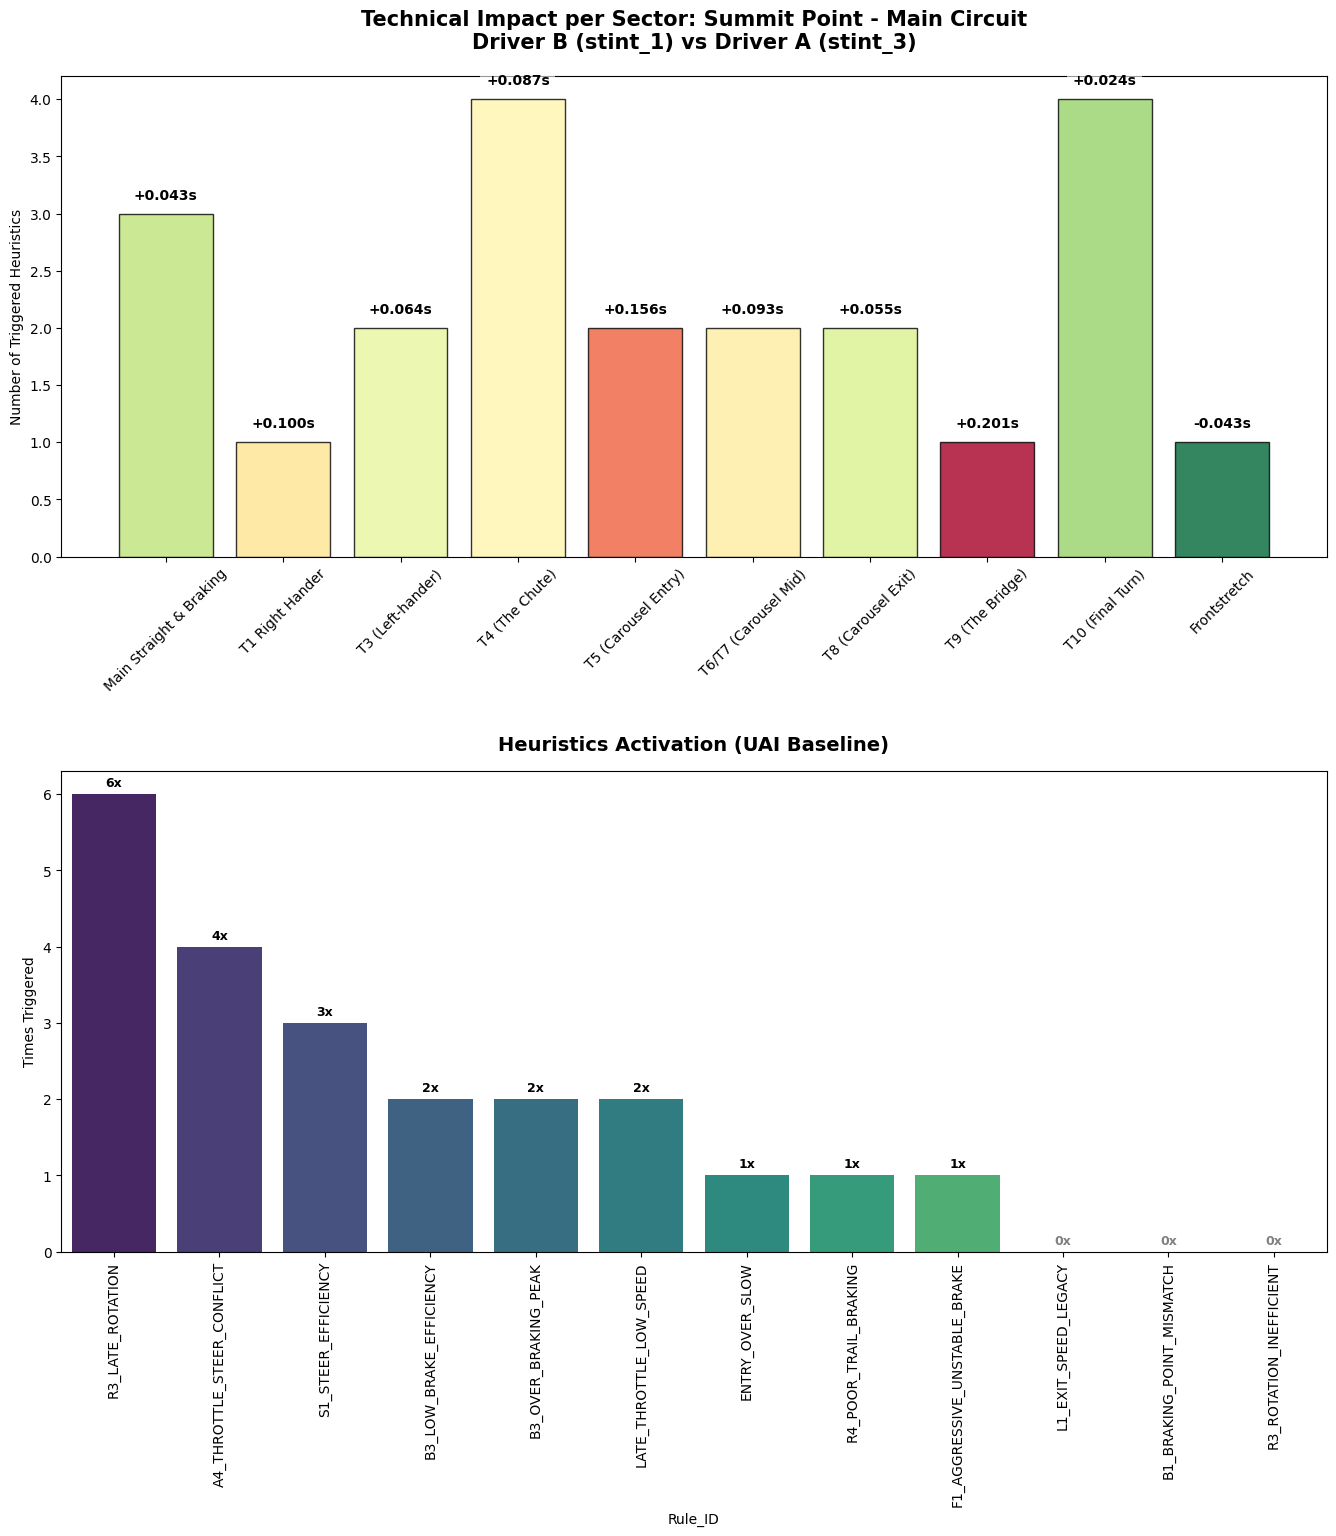

In [63]:
def analyze_heuristics_efficiency(master_df, rules):
    """
    Rebuilds the database ensuring ALL rules appear,
    even those that were never triggered.
    """
    efficiency_stats = {rule["id"]: 0 for rule in rules}

    for _, row in master_df.iterrows():
        data_a = {k.replace("_A", ""): v for k, v in row.items() if k.endswith("_A")}
        data_b = {k.replace("_B", ""): v for k, v in row.items() if k.endswith("_B")}
        data_b["SpeedStartDiff"] = row.get("SpeedStart_B", 0) - row.get("SpeedStart_A", 0)

        for rule in rules:
            try:
                if rule["condition"](data_a, data_b):
                    efficiency_stats[rule["id"]] += 1
            except:
                continue

    df_eff = pd.DataFrame(list(efficiency_stats.items()), columns=["Rule_ID", "Trigger_Count"])
    return df_eff


def plot_meta_analysis(df_insights, df_efficiency, track_name="Summit Point"):
    """
    Meta-Analysis Dashboard showing the distribution of technical errors per sector
    and global rule frequency.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 16))

    # --- PLOT 1: Distribution by Sector ---
    norm   = plt.Normalize(df_insights['Delta_Time'].min(), df_insights['Delta_Time'].max())
    colors = plt.cm.RdYlGn_r(norm(df_insights['Delta_Time']))
    bars1  = ax1.bar(df_insights['Turn'], df_insights['Alerts_Count'],
                     color=colors, edgecolor='black', alpha=0.8)

    ax1.set_title(f"Technical Impact per Sector: {track_name}\n"
                  f"{driver_b} ({STINT_TEST}) vs {driver_a} ({STINT_REF})",
                  fontsize=15, fontweight='bold', pad=20)
    ax1.set_ylabel("Number of Triggered Heuristics")
    ax1.tick_params(axis='x', rotation=45)

    for i, bar in enumerate(bars1):
        delta_val = df_insights.iloc[i]['Delta_Time']
        ax1.text(bar.get_x() + bar.get_width() / 2.,
                 bar.get_height() + 0.1,
                 f"{delta_val:+.3f}s",
                 ha='center', va='bottom', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    # --- PLOT 2: Global Ranking ---
    df_plot_eff = df_efficiency.sort_values("Trigger_Count", ascending=False)
    sns.barplot(data=df_plot_eff, x="Rule_ID", y="Trigger_Count", palette="viridis", ax=ax2)

    ax2.set_title("Heuristics Activation (UAI Baseline)",
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_ylabel("Times Triggered")
    ax2.set_xticks(range(len(df_plot_eff)))
    ax2.set_xticklabels(df_plot_eff["Rule_ID"], rotation=90, ha='center', fontsize=10)

    for i, v in enumerate(df_plot_eff["Trigger_Count"]):
        ax2.text(i, v + 0.1, f'{int(v)}x', ha='center', fontsize=9,
                 fontweight='bold', color='black' if v > 0 else 'gray')

    plt.tight_layout(pad=3.0)

    save_dir_path = Path(SAVE_DIR)
    file_name  = (f"meta_analysis_heuristics_{track_name.replace(' ', '_').lower()}_"
                  f"{driver_a}_vs_{driver_b}.png")
    save_path  = save_dir_path / file_name
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()


# --- STEP B: Generate plot variables ---
df_insights   = analyze_all_sectors(seg_cmp_final, DRIVING_RULES)
df_efficiency = analyze_heuristics_efficiency(seg_cmp_final, DRIVING_RULES)

# --- STEP C: Plot ---
plot_meta_analysis(df_insights, df_efficiency, track_name=TRACK_NAME)

# Resposta final com modelo de linguagem

In [ ]:
from __future__ import annotations
import json
import numpy as np
import pandas as pd
from IPython.display import Markdown

# %% 1. SYSTEM PROMPT COM LÓGICA DE CAUSALIDADE (MEMÓRIA)
SYSTEM_PROMPT = """
Você é um coach de pilotagem profissional de SimRacing. 
Sua tarefa é analisar os deltas de tempo e as heurísticas para melhorar o desempenho no Charlotte Roval 2025.

Instruções de Prioridade e Memória:
1) Os dados JSON já estão ordenados pela magnitude da perda de tempo (do maior prejuízo para o menor). MANTENHA esta ordem.
2) Se um setor apresentar a categoria 'Legado', explique ao piloto que a perda de tempo ali NÃO é um erro de execução atual, mas sim uma consequência da saída ruim na curva anterior.
3) Use os nomes oficiais das curvas para contexto geográfico (ex: T7, Bus Stop, Oval T1).
4) Seja objetivo: gere no máximo 2 bullets por curva, focando na causa raiz (DNA técnico ou Legado).
5) Se o delta_time_s for negativo ou zero, apenas escreva: "Execução consistente com a referência."

Formato da resposta:
- "### Curva X: [Nome] (Δt = +Y.YYYs)"
- Bullets técnicos baseados nas heurísticas fornecidas.
- Finalize com "### Resumo de Foco Técnico" listando as 3 prioridades da volta.
""".strip()

# %% 2. FUNÇÕES DE SUPORTE AO PROMPT
def _safe_float(x):
    try:
        if x is None: return None
        x = float(x)
        return x if np.isfinite(x) else None
    except: return None

def build_tips_payload_by_sector(
    seg_cmp: pd.DataFrame,
    sectors_dt: pd.DataFrame,
    interp_B: dict,
    edges: list = CUSTOM_EDGES,
    max_tips_per_sector: int = 2,
    loss_threshold: float = 0.010 
) -> dict:
    payload = {
        "meta": {
            "track": "Charlotte Roval 2025",
            "note": "Setores ordenados por perda de tempo. Inclui diagnóstico de legado."
        },
        "sectors": []
    }

    temp_sectors = []
    for sid in seg_cmp["Sector"].unique():
        dt_row = sectors_dt.loc[sectors_dt["Sector"] == sid, "DeltaTime_s"]
        dt = _safe_float(dt_row.iloc[0]) if not dt_row.empty else 0.0
        if dt > loss_threshold:
            temp_sectors.append({
                "id": int(sid),
                "delta": dt,
                "name": SECTOR_NAMES.get(sid, f"Setor {sid}")
            })

    # Ordenação Decrescente: Prioridade para onde se perde mais tempo
    temp_sectors = sorted(temp_sectors, key=lambda x: x["delta"], reverse=True)

    for s_info in temp_sectors:
        sid = s_info["id"]
        df_sector = seg_cmp[seg_cmp["Sector"] == sid].copy()
        tips = generate_sector_tips(df_sector, max_tips=max_tips_per_sector)

        tips_min = []
        for t in tips:
            tips_min.append({
                "priority": int(t.get("priority", 3)),
                "category": str(t.get("category", "Geral")),
                "message": str(t.get("message", ""))
            })

        payload["sectors"].append({
            "id": sid,
            "name": s_info["name"],
            "delta_time_s": s_info["delta"],
            "tips": tips_min
        })

    return payload

def build_user_prompt(payload: dict) -> str:
    return (
        "Analise os dados de telemetria abaixo e gere o feedback de coaching.\n\n"
        f"JSON DATA:\n{json.dumps(payload, ensure_ascii=False, indent=2)}"
    )

def call_ollama_chat(model, system_prompt, user_prompt, temperature=0.1):
    import ollama
    resp = ollama.chat(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        options={"temperature": float(temperature), "num_predict": 500}
    )
    return resp["message"]["content"]

# %% 3. EXECUÇÃO FINAL
OLLAMA_MODEL = "gemma3:12b"

# Gerar o payload com os novos limites de 18 setores
payload = build_tips_payload_by_sector(
    seg_cmp=seg_cmp,
    sectors_dt=sectors_AB,
    interp_B=interp_B,
    edges=CUSTOM_EDGES
)

user_p = build_user_prompt(payload)

print(f"Enviando {len(payload['sectors'])} setores para análise do {OLLAMA_MODEL}...")
final_markdown = call_ollama_chat(
    model=OLLAMA_MODEL,
    system_prompt=SYSTEM_PROMPT,
    user_prompt=user_p
)

display(Markdown(final_markdown))

Enviando 9 setores para análise do gemma3:12b...


- ### Curva 8: T9 (The Bridge) (Δt = +0.201291s)
    * Hesitação no acelerador na saída: A aplicação de potência está irregular. Concentre-se em uma aplicação suave e progressiva para maximizar a tração.
- ### Curva 5: T5 (Carousel Entry) (Δt = +0.156467s)
    * Frenagem: Analise a técnica de frenagem para otimizar a desaceleração.
    * Falta de Trail Braking: Soltar o freio cedo demais antes de virar está prejudicando a entrada na curva. Tente manter a pressão no freio enquanto vira o volante.
- ### Curva 2: T1 Right Hander (Δt = +0.100124s)
    * Conflito Acelerador x Volante: Exigir tração com o carro ainda muito virado está limitando a velocidade. Libere o volante para permitir que os pneus recuperem a aderência.
- ### Curva 6: T6/T7 (Carousel Mid) (Δt = +0.093494s)
    * Excesso de movimento no volante (Steer RMS alto): Movimentos bruscos no volante estão causando arrasto nos pneus e diminuindo a velocidade na curva. Seja mais suave e preciso.
    * Conflito Acelerador x Volante: Exigir tração com o carro ainda muito virado está limitando a velocidade. Libere o volante para permitir que os pneus recuperem a aderência.
- ### Curva 4: T4 (The Chute) (Δt = +0.087444s)
    * Rotação Atrasada: Você está atingindo o pico de rotação após o ápice da curva. Tente iniciar a rotação mais cedo para otimizar a trajetória.
    * Frenagem Ineficiente: A pressão excessiva nos freios pode estar travando as rodas ou sobrecarregando o ABS. Ajuste a técnica de frenagem para uma desaceleração mais eficiente.
- ### Curva 3: T3 (Left-hander) (Δt = +0.063905s)
    

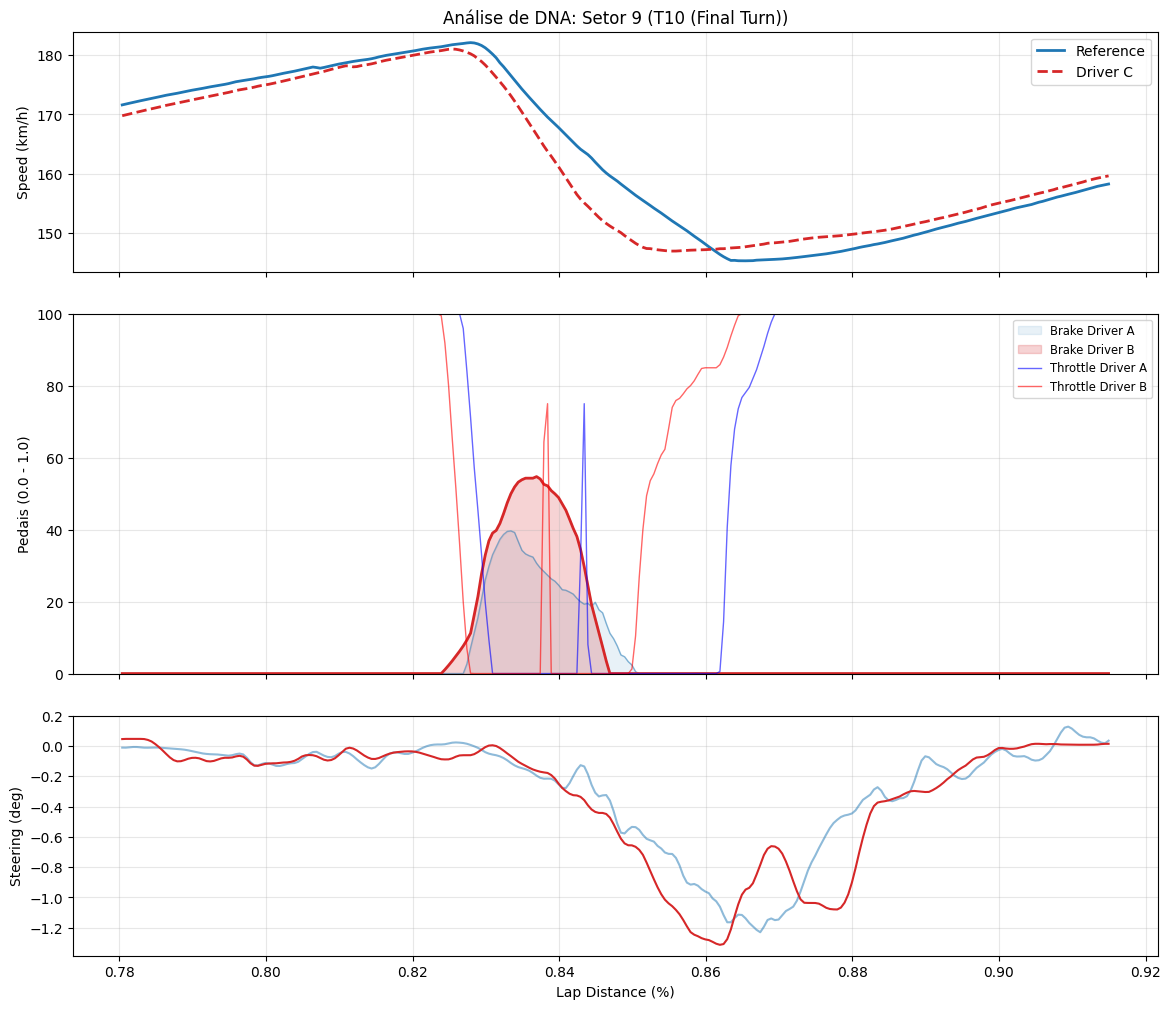

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_sector_dna(interp_a, interp_b, sector_id, edges=CUSTOM_EDGES):
    # 1. CONVERSÃO DE SEGURANÇA: Garante que estamos trabalhando com DataFrames
    if isinstance(interp_a, dict):
        interp_a = pd.DataFrame(interp_a)
    if isinstance(interp_b, dict):
        interp_b = pd.DataFrame(interp_b)

    # 2. Identifica os limites do setor
    start_pct = edges[sector_id - 1]
    end_pct = edges[sector_id]
    
    # 3. Filtra os dados de ambos os pilotos
    mask_a = (interp_a["LapDistPct"] >= start_pct) & (interp_a["LapDistPct"] <= end_pct)
    mask_b = (interp_b["LapDistPct"] >= start_pct) & (interp_b["LapDistPct"] <= end_pct)
    
    df_a = interp_a[mask_a].copy()
    df_b = interp_b[mask_b].copy()

    # Criando o canvas com proporções ajustadas para ver os pedais melhor
    fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True, 
                            gridspec_kw={'height_ratios': [1, 1.5, 1]})
    plt.subplots_adjust(hspace=0.15)
    
    # --- Subplot 1: VELOCIDADE ---
    axs[0].plot(df_a["LapDistPct"], df_a["speed"], label="Reference", color='#1f77b4', lw=2)
    axs[0].plot(df_b["LapDistPct"], df_b["speed"], label="Driver C", color='#d62728', lw=2, linestyle='--')
    axs[0].set_ylabel("Speed (km/h)")
    axs[0].set_title(f"Análise de DNA: Setor {sector_id} ({SECTOR_NAMES.get(sector_id, 'Setor ' + str(sector_id))})")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # --- Subplot 2: PEDAIS PROGRESSIVOS (Onde estava o problema do 0-1) ---
    # Usamos preenchimento (fill_between) para evidenciar a modulação/trail braking
    # Referência (A)
    axs[1].fill_between(df_a["LapDistPct"], 0, df_a["brake"], color='#1f77b4', alpha=0.1, label="Brake Driver A")
    axs[1].plot(df_a["LapDistPct"], df_a["brake"], color='#1f77b4', lw=1, alpha=0.5)
    
    # Driver C (B) - Linha sólida e preenchimento mais forte para destacar a curva
    axs[1].fill_between(df_b["LapDistPct"], 0, df_b["brake"], color='#d62728', alpha=0.2, label="Brake Driver B")
    axs[1].plot(df_b["LapDistPct"], df_b["brake"], color='#d62728', lw=2)

    # Acelerador (Throttle) como referência de fundo
    axs[1].plot(df_a["LapDistPct"], df_a["throttle"], color='blue', lw=1, alpha=0.6, label="Throttle Driver A")
    axs[1].plot(df_b["LapDistPct"], df_b["throttle"], color='red', lw=1, alpha=0.6, label="Throttle Driver B")
    
    axs[1].set_ylabel("Pedais (0.0 - 1.0)")
    axs[1].set_ylim(-0.05, 100)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc='upper right', fontsize='small')

    # --- Subplot 3: VOLANTE ---
    # Se a coluna for 'steering' ou 'SteeringWheelAngle', ajustamos aqui:
    steer_col = "SteeringWheelAngle" if "SteeringWheelAngle" in df_a.columns else "steering"
    
    axs[2].plot(df_a["LapDistPct"], df_a[steer_col], color='#1f77b4', lw=1.5, alpha=0.5)
    axs[2].plot(df_b["LapDistPct"], df_b[steer_col], color='#d62728', lw=1.5)
    axs[2].set_ylabel("Steering (deg)")
    axs[2].set_xlabel("Lap Distance (%)")
    axs[2].grid(True, alpha=0.3)

    plt.show()

# EXECUÇÃO
plot_sector_dna(interp_A, interp_B, sector_id=9)